In [63]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from time import perf_counter

# ====== Matplotlib defaults for pub-quality (no custom colors) ======
plt.rcParams.update({
    "figure.figsize": (10, 4.5),
    "figure.dpi": 120,
    "axes.grid": True,
    "grid.alpha": 0.3,
    "axes.titlesize": 14,
    "axes.labelsize": 12,
    "xtick.labelsize": 10,
    "ytick.labelsize": 10,
    "legend.frameon": False,
})

# ====== Robust stats ======
def mad(x):
    x = np.asarray(x)
    med = np.median(x)
    return np.median(np.abs(x - med))

def robust_z(x):
    x = pd.Series(x)
    m = x.median()
    M = mad(x)
    if M == 0:
        s = x.std(ddof=1)
        return (x - x.mean()) / (s if s>0 else 1.0)
    return 0.67448975 * (x - m) / M

# ====== Event-based evaluation (tolerant spike matching) ======
def event_prf(flags: pd.Series, truth: pd.Series, tolerance=2):
    flags = flags.reindex(truth.index).fillna(False)
    f_idx = np.where(flags.values)[0].tolist()
    t_idx = np.where(truth.values)[0].tolist()

    tp = 0
    used_truth = set()
    for i in f_idx:
        candidates = [j for j in t_idx if abs(j - i) <= tolerance and j not in used_truth]
        if candidates:
            j = min(candidates, key=lambda j: abs(j - i))
            used_truth.add(j)
            tp += 1
    fp = len(f_idx) - tp
    fn = len(t_idx) - tp
    P = tp/(tp+fp) if (tp+fp)>0 else 0.0
    R = tp/(tp+fn) if (tp+fn)>0 else 0.0
    F1 = 2*P*R/(P+R) if (P+R)>0 else 0.0
    return dict(tp=tp, fp=fp, fn=fn, precision=P, recall=R, f1=F1)

# ====== Plotting helpers ======
def plot_series_with_truth_and_flags(ts: pd.Series, truth: pd.Series, flags: pd.Series, title="", save=False):
    ts = ts.sort_index()
    truth = truth.reindex(ts.index).fillna(False)
    flags = flags.reindex(ts.index).fillna(False)
    plt.figure()
    plt.plot(ts.index, ts.values, label=ts.name or "series")
    if truth.any():
        plt.scatter(ts.index[truth], ts.values[truth], s=18, label="ground truth")
    if flags.any():
        plt.scatter(ts.index[flags], ts.values[flags], s=28, label="detected")
    plt.title(title); plt.xlabel("Time"); plt.ylabel("Value"); plt.legend(); plt.tight_layout(); 
    if save:
        _savefig(os.path.join("figs", f"data.png"))
    plt.show()

def barplot(values, labels, title, ylabel):
    order = np.argsort(values)[::-1]
    values = np.array(values)[order]
    labels = np.array(labels)[order]
    plt.figure(figsize=(10, 4.2))
    plt.bar(range(len(values)), values)
    plt.xticks(range(len(values)), labels, rotation=30, ha="right")
    plt.title(title); plt.ylabel(ylabel); plt.tight_layout(); plt.show()

def scatter_perf(x, y, labels, title, xlabel, ylabel, sizes=None):
    plt.figure(figsize=(8.8, 4.8))
    if sizes is None:
        plt.scatter(x, y)
    else:
        plt.scatter(x, y, s=sizes)
    for xi, yi, lab in zip(x, y, labels):
        plt.annotate(lab, (xi, yi), xytext=(5,5), textcoords="offset points", fontsize=9)
    plt.title(title); plt.xlabel(xlabel); plt.ylabel(ylabel); plt.tight_layout(); plt.show()

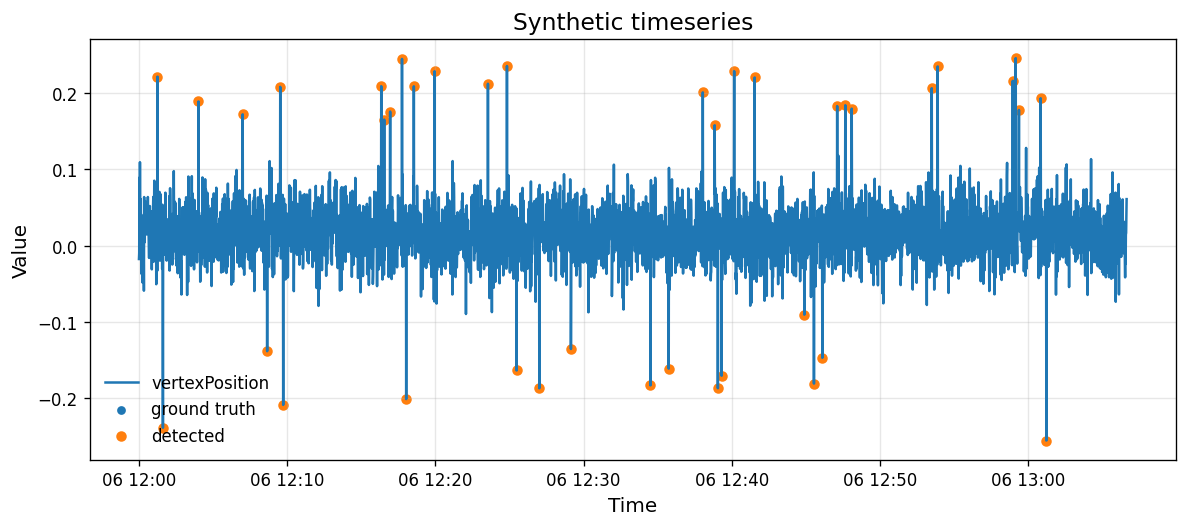

saved: figs/data.png


In [64]:
def sample_indices_with_min_sep(n, k, min_sep, rng):
    chosen = []
    attempts = 0
    while len(chosen) < k and attempts < 50_000:
        cand = int(rng.integers(0, n))
        if all(abs(cand - c) >= min_sep for c in chosen):
            chosen.append(cand)
        attempts += 1
    if len(chosen) < k:
        step = max(min_sep, n // max(1, k+1))
        chosen = list(range(step, step*(k+1), step))[:k]
    return sorted(chosen)

def make_spike_only(n=5000, spike_frac=0.01, spike_amp=6.0, min_sep=6, seed=123):
    rng = np.random.default_rng(seed)
    idx = pd.date_range("2025-07-06 12:00:00", periods=n, freq="s")
    base = rng.normal(0, 0.02, size=n)
    timeA = base + rng.normal(0, 0.02, size=n) - 0.08
    timeC = base + rng.normal(0, 0.02, size=n) - 0.08
    deltaT = timeA - timeC
    sumT   = timeA + timeC
    vertex = 0.25*deltaT - 0.10*sumT + 0.60*(deltaT**2) + rng.normal(0, 0.03, size=n)

    k = max(1, int(spike_frac * n))
    spike_idx = sample_indices_with_min_sep(n, k, min_sep, rng)

    rstd = 1.4826 * mad(vertex)
    jump = spike_amp * (rstd if rstd>0 else 1.0)
    signs = rng.choice([-1,1], size=k)
    vertex_spiked = vertex.copy()
    for s, j in zip(spike_idx, signs):
        vertex_spiked[s] += j * jump

    df = pd.DataFrame({"timeA": timeA, "timeC": timeC, "vertexPosition": vertex_spiked}, index=idx)
    df["deltaT"] = df["timeA"] - df["timeC"]
    df["sumT"]   = df["timeA"] + df["timeC"]
    truth = pd.Series(False, index=idx, name="is_spike")
    truth.iloc[spike_idx] = True
    return df, truth

# Quick look
_syn, _truth = make_spike_only(n=4000, spike_frac=0.01, spike_amp=6.0, min_sep=6, seed=7)
plot_series_with_truth_and_flags(_syn["vertexPosition"], _truth, _truth, "Synthetic timeseries", save=True)

In [33]:
# ---------- Statistical ----------
def detect_robustZ(series: pd.Series, z_thr=6.0):
    z = robust_z(series)
    return (np.abs(z) >= z_thr)

def engineer_for_hampel(series: pd.Series, window=41):
    W = int(window) if int(window)%2==1 else int(window)+1
    med = series.rolling(W, center=True).median()
    mad_win = series.rolling(W, center=True).apply(mad, raw=False)
    return med, mad_win

def detect_hampel(series: pd.Series, k=5.0, window=41):
    med, mad_win = engineer_for_hampel(series, window)
    band = 1.4826 * mad_win * k
    return ((series > med + band) | (series < med - band)).fillna(False)

# ---------- Residual (conditional on ΔT,S) ----------
try:
    from sklearn.preprocessing import RobustScaler
    from sklearn.linear_model import HuberRegressor, Ridge
    from sklearn.preprocessing import StandardScaler
    from sklearn.decomposition import PCA
    from sklearn.ensemble import IsolationForest, RandomForestClassifier
    from sklearn.svm import OneClassSVM
    from sklearn.neighbors import LocalOutlierFactor
    SKLEARN = True
except Exception:
    SKLEARN = False

def detect_residual_conditional(df: pd.DataFrame, z_thr=6.0):
    if not SKLEARN:
        return pd.Series(False, index=df.index)
    X = pd.DataFrame({
        "deltaT": df["deltaT"], "sumT": df["sumT"],
        "deltaT2": df["deltaT"]**2, "sumT2": df["sumT"]**2
    })
    X = X.dropna()
    y = df.loc[X.index, "vertexPosition"]
    sc = RobustScaler().fit(X.values)
    hub = HuberRegressor().fit(sc.transform(X.values), y.values)
    resid = pd.Series(y.values - hub.predict(sc.transform(X.values)), index=X.index)
    z = robust_z(resid)
    flags = (np.abs(z) >= z_thr)
    return flags.reindex(df.index, fill_value=False)

# ---------- Unsupervised ----------
def build_uns_feats(df: pd.DataFrame):
    feats = pd.DataFrame({
        "vertex": df["vertexPosition"],
        "deltaT": df["deltaT"],
        "sumT": df["sumT"],
        "d_vertex": df["vertexPosition"].diff(),
        "roll_std": df["vertexPosition"].rolling(41, center=True).std(),
    }).replace([np.inf, -np.inf], np.nan).dropna()
    return feats

def threshold_by_quantile(score: pd.Series, train_index: pd.Index | None, q=0.995):
    s = score.dropna().sort_index()
    if train_index is not None:
        train_idx = s.index.intersection(train_index)
        if len(train_idx) == 0:
            split = max(50, int(0.3 * len(s)))
            train = s.iloc[:split]
        else:
            train = s.loc[train_idx]
    else:
        split = max(50, int(0.3 * len(s)))
        train = s.iloc[:split]
    thr = np.nanquantile(train.values, q)
    return (s >= thr), thr

def score_pca(df: pd.DataFrame, n_components=4, train_frac=0.3):
    feats = build_uns_feats(df)
    idx = feats.index
    split = max(100, int(train_frac * len(feats)))
    Xtr, X = feats.values[:split], feats.values
    sc = StandardScaler().fit(Xtr)
    Xs = sc.transform(X)
    pca = PCA(n_components=min(n_components, Xs.shape[1])).fit(Xs[:split])
    rec = pca.inverse_transform(pca.transform(Xs))
    err = ((Xs - rec)**2).sum(axis=1)
    return pd.Series(err, index=idx), idx[:split]

def score_iforest(df: pd.DataFrame, contamination=0.01, train_frac=0.3):
    feats = build_uns_feats(df)
    idx = feats.index
    split = max(100, int(train_frac * len(feats)))
    Xtr, X = feats.values[:split], feats.values
    sc = StandardScaler().fit(Xtr)
    Xtr_s = sc.transform(Xtr); Xs = sc.transform(X)
    iforest = IsolationForest(contamination=contamination, random_state=0).fit(Xtr_s)
    score = -iforest.score_samples(Xs)
    return pd.Series(score, index=idx), idx[:split]

def score_ocsvm(df: pd.DataFrame, nu=0.01, gamma="scale", train_frac=0.3, mode="decision"):
    """
    OC-SVM scoring.
    mode='decision': use decision_function (>0 normal, <0 anomaly). We return score = -decision (higher = more anomalous).
    mode='quantile': use -score_samples and threshold via quantile on the train block.
    """
    if not SKLEARN:
        return pd.Series(index=df.index, dtype=float), df.index[:0]

    feats = build_uns_feats(df)
    idx = feats.index
    split = max(100, int(train_frac * len(feats)))
    Xtr, X = feats.values[:split], feats.values
    sc = StandardScaler().fit(Xtr)
    Xtr_s = sc.transform(Xtr); Xs = sc.transform(X)

    oc = OneClassSVM(nu=nu, gamma=gamma).fit(Xtr_s)

    if mode == "decision":
        dec = oc.decision_function(Xs).ravel()   # >0 normal, <0 anomaly
        score = pd.Series(-dec, index=idx, name=f"OCSVM_decision_{gamma}")
        train_idx = idx[:split]
        return score, train_idx          # flags = (score > 0)
    else:
        raw = -oc.score_samples(Xs)
        score = pd.Series(raw, index=idx, name=f"OCSVM_score_{gamma}")
        train_idx = idx[:split]
        return score, train_idx

def score_lof(df: pd.DataFrame, n_neighbors=35, train_frac=0.3):
    feats = build_uns_feats(df)
    idx = feats.index
    split = max(100, int(train_frac * len(feats)))
    Xtr, X = feats.values[:split], feats.values
    sc = StandardScaler().fit(Xtr)
    Xtr_s = sc.transform(Xtr); Xs = sc.transform(X)
    lof = LocalOutlierFactor(n_neighbors=n_neighbors, novelty=True).fit(Xtr_s)
    score = -lof.score_samples(Xs)
    return pd.Series(score, index=idx), idx[:split]

# ---------- Supervised (RandomForest on windowed features) ----------
def make_windowed_ml_features(df: pd.DataFrame, truth: pd.Series, lags=10):
    X = pd.DataFrame(index=df.index)
    X["vertex"] = df["vertexPosition"]
    X["deltaT"] = df["deltaT"]
    X["sumT"]   = df["sumT"]
    for L in range(1, lags+1):
        X[f"vertex_lag{L}"] = df["vertexPosition"].shift(L)
        X[f"deltaT_lag{L}"] = df["deltaT"].shift(L)
        X[f"sumT_lag{L}"]   = df["sumT"].shift(L)
    X = X.dropna()
    y = truth.reindex(X.index).fillna(False)
    return X, y

def oof_supervised_rf(df: pd.DataFrame, truth: pd.Series,
                      lags=10, n_estimators=200, max_depth=None, class_weight="balanced",
                      train_frac=0.4, val_frac=0.2, test_frac=0.1, step_frac=None, tolerance=2):
    """
    Walk-forward OOF:
      [train | val] -> choose threshold on val; predict next [test] block.
      Slide by step (default=test size). Concatenate predictions to cover the series.
    Times reported are cumulative fit/predict.
    """
    if not SKLEARN:
        return pd.Series(False, index=df.index), dict()

    # build windowed features
    X, y = make_windowed_ml_features(df, truth, lags=lags)
    n = len(X)
    if n < 500:
        # fall back to single split if too short
        flags, meta = supervised_rf(df, truth, lags=lags, n_estimators=n_estimators, max_depth=max_depth,
                                    class_weight=class_weight, train_frac=0.6, val_frac=0.2)
        return flags, meta

    n_train = max(200, int(train_frac * n))
    n_val   = max(100, int(val_frac * n))
    n_test  = max(100, int(test_frac * n))
    step    = n_test if step_frac is None else max(50, int(step_frac * n))

    from sklearn.ensemble import RandomForestClassifier
    sc_total_fit, sc_total_pred, train_fracs = [], [], []

    flags_full = pd.Series(False, index=df.index)
    start = 0
    while True:
        i_tr0 = start
        i_tr1 = i_tr0 + n_train
        i_va1 = i_tr1 + n_val
        i_te1 = min(i_va1 + n_test, n)
        if i_te1 - i_tr0 < (n_train + n_val + 20):  # not enough ahead
            break
        Xtr, ytr = X.iloc[i_tr0:i_tr1], y.iloc[i_tr0:i_tr1]
        Xva, yva = X.iloc[i_tr1:i_va1], y.iloc[i_tr1:i_va1]
        Xte, yte = X.iloc[i_va1:i_te1], y.iloc[i_va1:i_te1]

        from sklearn.preprocessing import StandardScaler
        sc = StandardScaler(with_mean=True, with_std=True).fit(Xtr.values)

        RF = RandomForestClassifier(
            n_estimators=n_estimators,
            max_depth=max_depth,
            class_weight=class_weight,
            random_state=0,
            n_jobs=-1
        )

        t0 = perf_counter(); RF.fit(sc.transform(Xtr.values), ytr.values); t_fit = perf_counter()-t0

        # choose threshold on validation by maximizing event-F1
        proba_va = RF.predict_proba(sc.transform(Xva.values))[:,1]
        thr_grid = np.linspace(0.05, 0.95, 37)
        best_thr, best_f1 = 0.5, -1
        for th in thr_grid:
            flags_va = pd.Series(proba_va >= th, index=Xva.index)
            f = event_prf(flags_va, truth.reindex(flags_va.index), tolerance=tolerance)["f1"]
            if f > best_f1:
                best_f1, best_thr = f, th

        # predict the test block
        t1 = perf_counter(); proba_te = RF.predict_proba(sc.transform(Xte.values))[:,1]; t_pred = perf_counter()-t1
        flags_te = pd.Series(proba_te >= best_thr, index=Xte.index)

        # write flags back to full index
        f_series_index = flags_full.index.intersection(flags_te.index)
        flags_full.loc[f_series_index] = flags_te.loc[f_series_index]

        sc_total_fit.append(t_fit); sc_total_pred.append(t_pred)
        train_fracs.append(len(Xtr) / n)

        if i_te1 >= n: break
        start += step

    meta = dict(
        fit_time=sum(sc_total_fit),
        pred_time=sum(sc_total_pred),
        train_frac=float(np.mean(train_fracs)) if train_fracs else 0.0,
        lags=lags, n_estimators=n_estimators, max_depth=max_depth, class_weight=class_weight
    )
    return flags_full, meta

In [18]:
def unsupervised_scores(df):
    """
    Build a feature matrix (instantaneous + rolling) and compute anomaly scores:
      - PCA reconstruction error
      - IsolationForest
      - One-Class SVM
      - LOF (novelty via train/test split)
    Thresholds picked by training-quantile (e.g., 99.5%) on an initial normal window.
    """
    out = {}
    if not SKLEARN:
        return out

    feats = pd.DataFrame({
        "vertex": df["vertexPosition"],
        "deltaT": df["deltaT"],
        "sumT": df["sumT"],
        "roll_std": df["roll_mad"]*1.4826,
        "d_vertex": df["d_vertex"],
    }).replace([np.inf,-np.inf], np.nan).dropna()
    idx = feats.index
    scaler = StandardScaler().fit(feats.values)
    X = scaler.transform(feats.values)

    # training split: first 30% (assume mostly normal)
    n = len(idx); split = max(100, int(0.3*n))
    Xtr, Xte = X[:split], X[split:]; idxtr, idxte = idx[:split], idx[split:]

    # PCA reconstruction error
    pca = PCA(n_components=min(5, Xtr.shape[1])).fit(Xtr)
    rec = pca.inverse_transform(pca.transform(X))
    pca_err = ((X - rec)**2).sum(axis=1)
    out["PCA_error"] = pd.Series(pca_err, index=idx)

    # Isolation Forest (score_samples higher=more normal -> invert)
    iforest = IsolationForest(contamination=0.01, random_state=0).fit(Xtr)
    if_score = -iforest.score_samples(X)  # higher=more anomalous
    out["IForest"] = pd.Series(if_score, index=idx)

    # One-Class SVM
    oc = OneClassSVM(nu=0.01, gamma="scale").fit(Xtr)
    oc_score = -oc.score_samples(X)
    out["OCSVM"] = pd.Series(oc_score, index=idx)

    # LOF novelty
    lof = LocalOutlierFactor(n_neighbors=35, novelty=True).fit(Xtr)
    lof_score = -lof.score_samples(X)
    out["LOF"] = pd.Series(lof_score, index=idx)

    return out

def threshold_by_quantile(score: pd.Series, train_index: pd.Index | None = None, q=0.995):
    """
    Pick a threshold at the q-quantile of a TRAIN subset.
    If train_index is provided, intersect it with score.index; otherwise
    default to the first 30% of *this score's* timeline.
    """
    s = score.dropna().sort_index()
    if train_index is not None:
        train_idx = s.index.intersection(train_index)
        if len(train_idx) == 0:
            # fallback: first 30% of available score samples
            split = max(50, int(0.3 * len(s)))
            train = s.iloc[:split]
        else:
            train = s.loc[train_idx]
    else:
        split = max(50, int(0.3 * len(s)))
        train = s.iloc[:split]

    thr = np.nanquantile(train.values, q)
    flags = s >= thr
    return flags, thr

In [25]:
def gridsearch_statistical(series, truth, tolerance=2):
    results = []
    # Robust-Z
    for z_thr in [3.0, 4.0, 5.0, 6.0, 7.0]:
        t0=perf_counter(); flags = detect_robustZ(series, z_thr=z_thr); pred_t=perf_counter()-t0
        m = event_prf(flags, truth, tolerance=tolerance)
        results.append(dict(method=f"RobustZ|z|>={z_thr}", category="statistical",
                            precision=m["precision"], recall=m["recall"], f1=m["f1"],
                            fit_time=0.0, pred_time=pred_t, train_frac=0.0))
    # Hampel
    for k in [3.0, 4.0, 5.0, 6.0]:
        for W in [31, 41, 61]:
            t0=perf_counter(); flags = detect_hampel(series, k=k, window=W); pred_t=perf_counter()-t0
            m = event_prf(flags, truth, tolerance=tolerance)
            results.append(dict(method=f"Hampel k={k} W={W}", category="statistical",
                                precision=m["precision"], recall=m["recall"], f1=m["f1"],
                                fit_time=0.0, pred_time=pred_t, train_frac=0.0))
    return results

def gridsearch_unsupervised(df, truth, tolerance=2):
    if not SKLEARN:
        return []
    results = []
    # PCA
    for nc in [2,3,4,5]:
        t0=perf_counter(); score, train_idx = score_pca(df, n_components=nc, train_frac=0.3); fit_t=perf_counter()-t0
        flags, thr = threshold_by_quantile(score, train_idx, q=0.995)
        m = event_prf(flags, truth.reindex(flags.index), tolerance=tolerance)
        results.append(dict(method=f"PCA nc={nc}", category="unsupervised",
                            precision=m["precision"], recall=m["recall"], f1=m["f1"],
                            fit_time=fit_t, pred_time=0.0, train_frac=len(train_idx)/len(score)))
    # IF
    for cont in [0.005, 0.01, 0.02]:
        t0=perf_counter(); score, train_idx = score_iforest(df, contamination=cont, train_frac=0.3); fit_t=perf_counter()-t0
        flags, thr = threshold_by_quantile(score, train_idx, q=0.995)
        m = event_prf(flags, truth.reindex(flags.index), tolerance=tolerance)
        results.append(dict(method=f"IForest c={cont}", category="unsupervised",
                            precision=m["precision"], recall=m["recall"], f1=m["f1"],
                            fit_time=fit_t, pred_time=0.0, train_frac=len(train_idx)/len(score)))
    # OCSVM
    for nu in [0.005, 0.01, 0.02]:
        t0=perf_counter(); score, train_idx = score_ocsvm(df, nu=nu, gamma="scale", train_frac=0.3); fit_t=perf_counter()-t0
        flags, thr = threshold_by_quantile(score, train_idx, q=0.995)
        m = event_prf(flags, truth.reindex(flags.index), tolerance=tolerance)
        results.append(dict(method=f"OCSVM nu={nu}", category="unsupervised",
                            precision=m["precision"], recall=m["recall"], f1=m["f1"],
                            fit_time=fit_t, pred_time=0.0, train_frac=len(train_idx)/len(score)))
    # LOF
    for nn in [25, 35, 55]:
        t0=perf_counter(); score, train_idx = score_lof(df, n_neighbors=nn, train_frac=0.3); fit_t=perf_counter()-t0
        flags, thr = threshold_by_quantile(score, train_idx, q=0.995)
        m = event_prf(flags, truth.reindex(flags.index), tolerance=tolerance)
        results.append(dict(method=f"LOF k={nn}", category="unsupervised",
                            precision=m["precision"], recall=m["recall"], f1=m["f1"],
                            fit_time=fit_t, pred_time=0.0, train_frac=len(train_idx)/len(score)))
    return results

def gridsearch_supervised(df, truth, tolerance=2):
    if not SKLEARN:
        return []
    results = []
    for lags in [6, 10, 16]:
        for n_est in [100, 200, 400]:
            for md in [None, 8, 16]:
                flags, meta = supervised_rf(df, truth, lags=lags, n_estimators=n_est, max_depth=md)
                m = event_prf(flags, truth, tolerance=tolerance)
                results.append(dict(method=f"RF lags={lags} n={n_est} md={md}", category="supervised",
                                    precision=m["precision"], recall=m["recall"], f1=m["f1"],
                                    fit_time=meta.get("fit_time",0.0), pred_time=meta.get("pred_time",0.0),
                                    train_frac=meta.get("train_frac",0.0)))
    return results

Statistical grid:   0%|          | 0/17 [00:00<?, ?it/s]

Unsupervised grid:   0%|          | 0/13 [00:00<?, ?it/s]

Supervised grid (RF OOF):   0%|          | 0/27 [00:00<?, ?it/s]

,method,category,precision,recall,f1,fit_time,pred_time,train_frac
0,RobustZ|z|>=4.0,statistical,1.000000,0.986111,0.993007,0.0,0.001820,0.0
1,Hampel k=4.0 W=61,statistical,0.985075,0.916667,0.949640,0.0,0.930697,0.0
2,RobustZ|z|>=5.0,statistical,1.000000,0.888889,0.941176,0.0,0.001820,0.0
3,RobustZ|z|>=3.0,statistical,0.888889,1.000000,0.941176,0.0,0.002802,0.0
4,Hampel k=4.0 W=41,statistical,0.883117,0.944444,0.912752,0.0,0.962046,0.0
5,Hampel k=4.0 W=31,statistical,0.893333,0.930556,0.911565,0.0,0.924526,0.0
6,Hampel k=5.0 W=61,statistical,1.000000,0.791667,0.883721,0.0,0.707716,0.0
7,Hampel k=5.0 W=31,statistical,0.981818,0.750000,0.850394,0.0,0.716965,0.0
8,Hampel k=5.0 W=41,statistical,0.981481,0.736111,0.841270,0.0,0.612235,0.0
9,Hampel k=3.0 W=61,statistical,0.689320,0.986111,0.811429,0.0,0.809402,0.0


Best per category:
  Statistical : {'method': 'RobustZ|z|>=4.0', 'category': 'statistical', 'precision': np.float64(1.0), 'recall': np.float64(0.9861111111111112), 'f1': np.float64(0.993006993006993), 'fit_time': np.float64(0.0), 'pred_time': np.float64(0.0018198410034528933), 'train_frac': np.float64(0.0)}
  Unsupervised: {'method': 'PCA nc=4', 'category': 'unsupervised', 'precision': np.float64(1.0), 'recall': np.float64(0.5277777777777778), 'f1': np.float64(0.6909090909090909), 'fit_time': np.float64(0.005107856006361544), 'pred_time': np.float64(0.0), 'train_frac': np.float64(0.3)}
  Supervised  : {'method': 'RF(OOF) lags=16 n=100 md=None', 'category': 'supervised', 'precision': np.float64(1.0), 'recall': np.float64(0.3472222222222222), 'f1': np.float64(0.5154639175257731), 'fit_time': np.float64(1.676338517005206), 'pred_time': np.float64(0.21796994700707728), 'train_frac': np.float64(0.39989973262032086)}


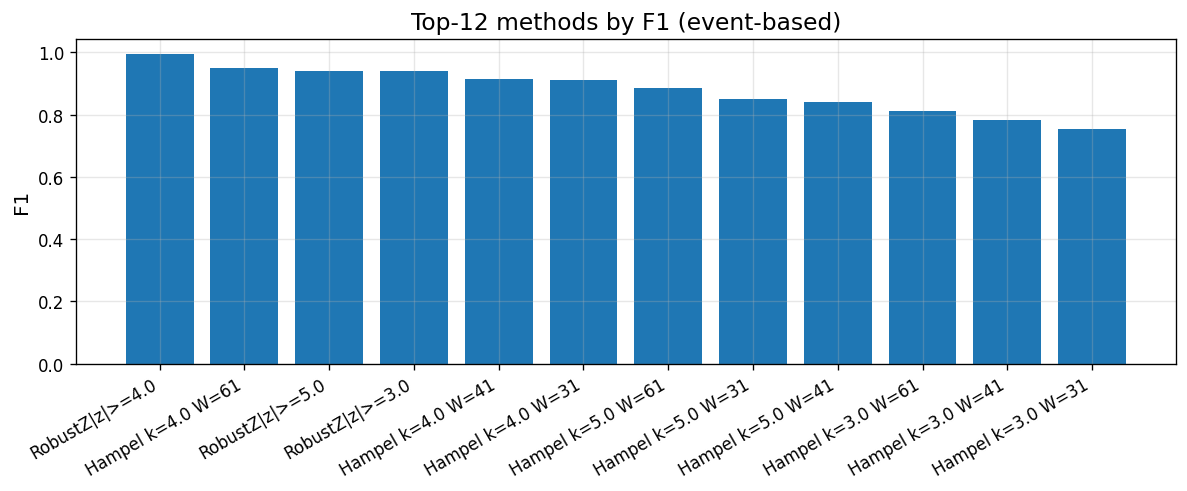

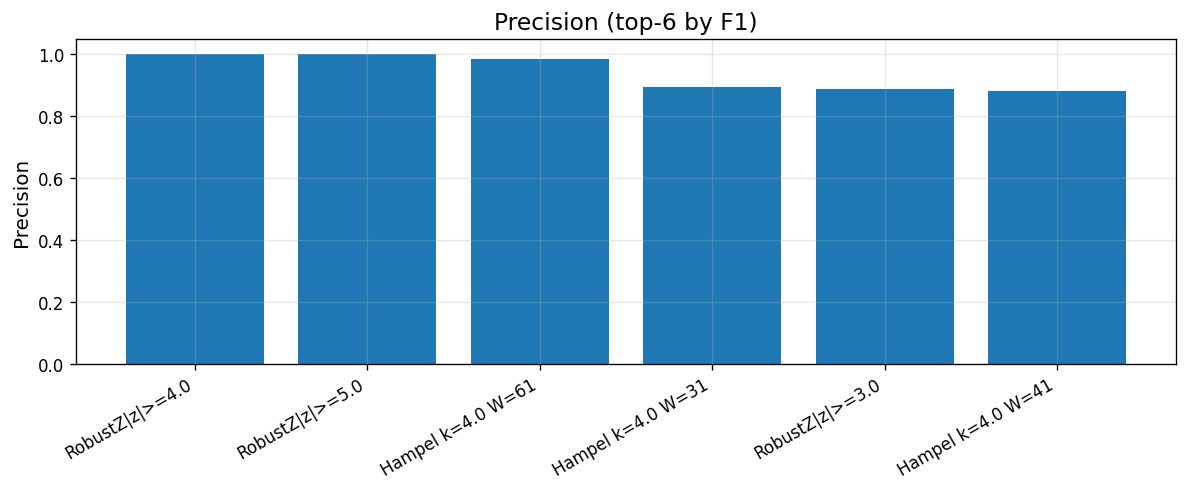

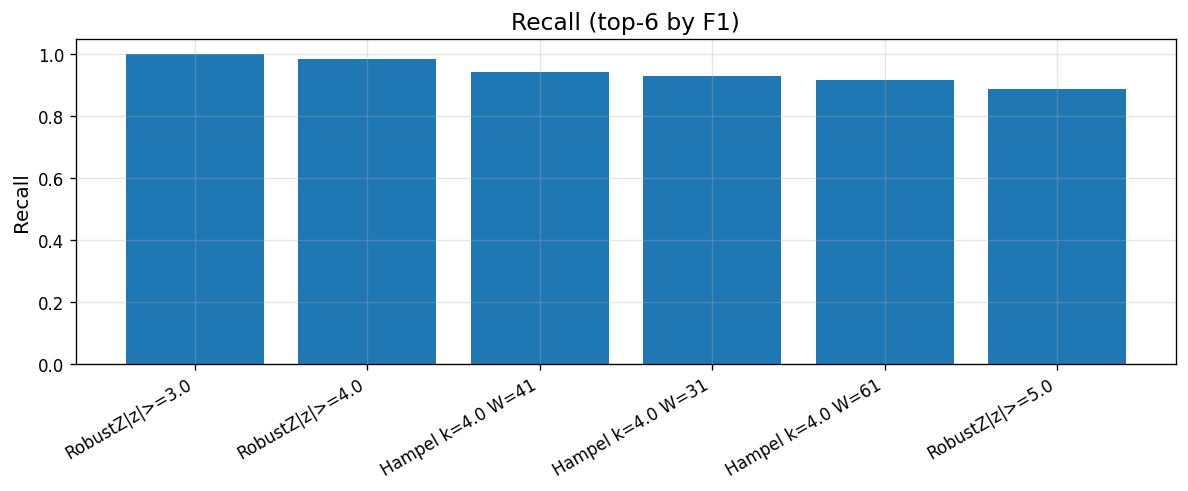

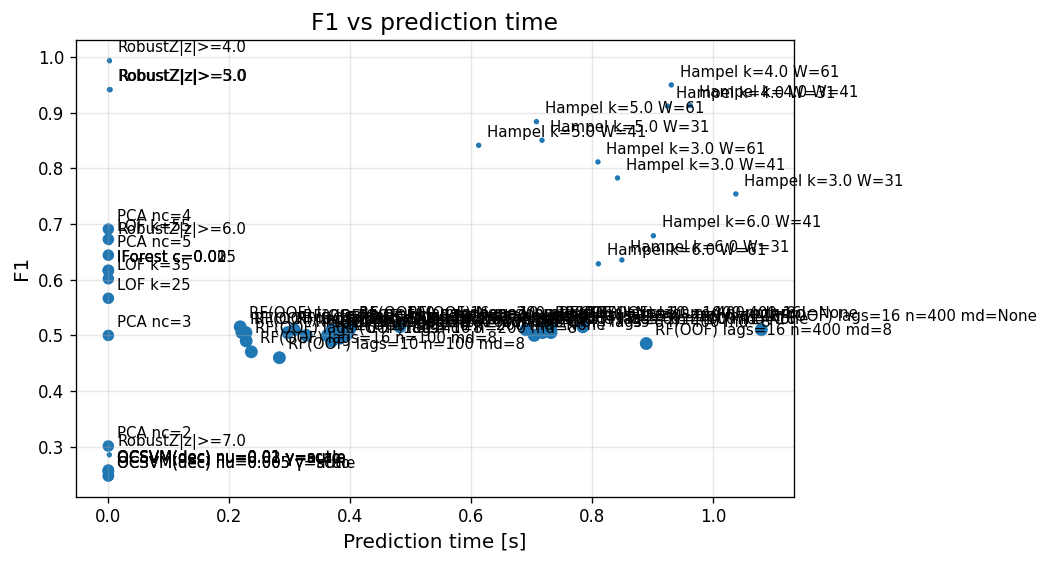

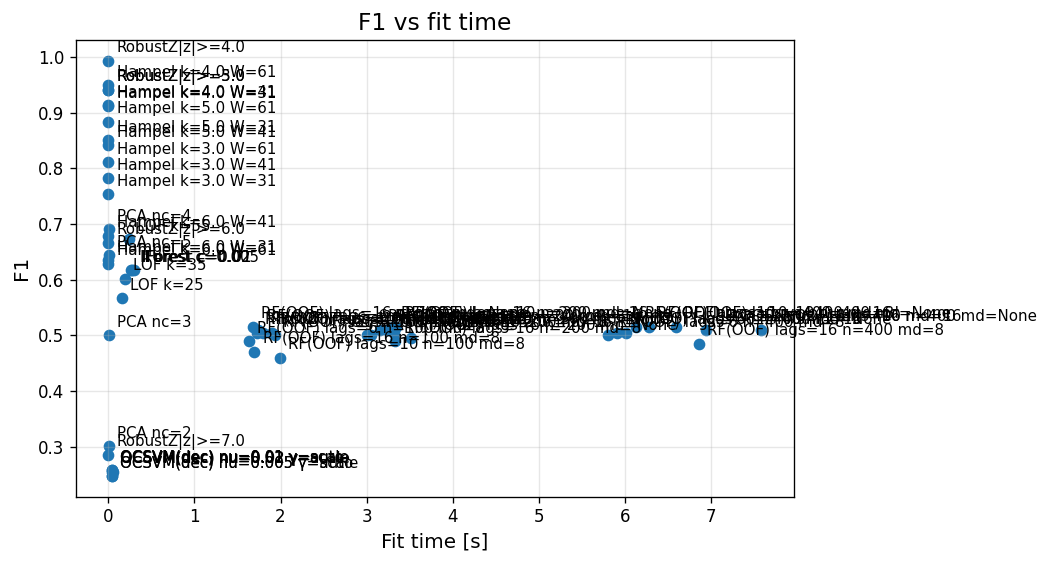

Plot chosen methods:   0%|          | 0/3 [00:00<?, ?it/s]

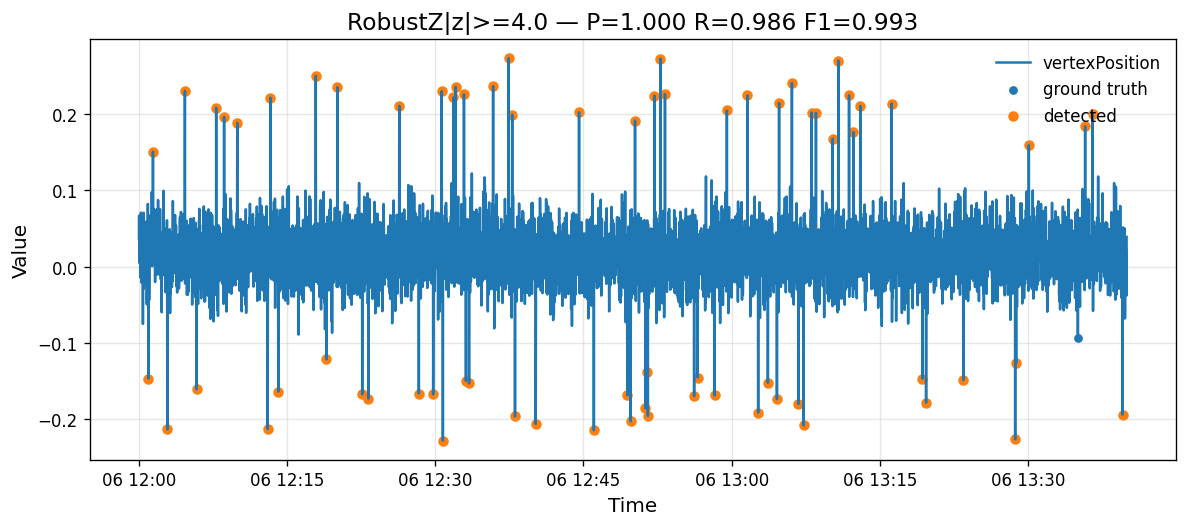

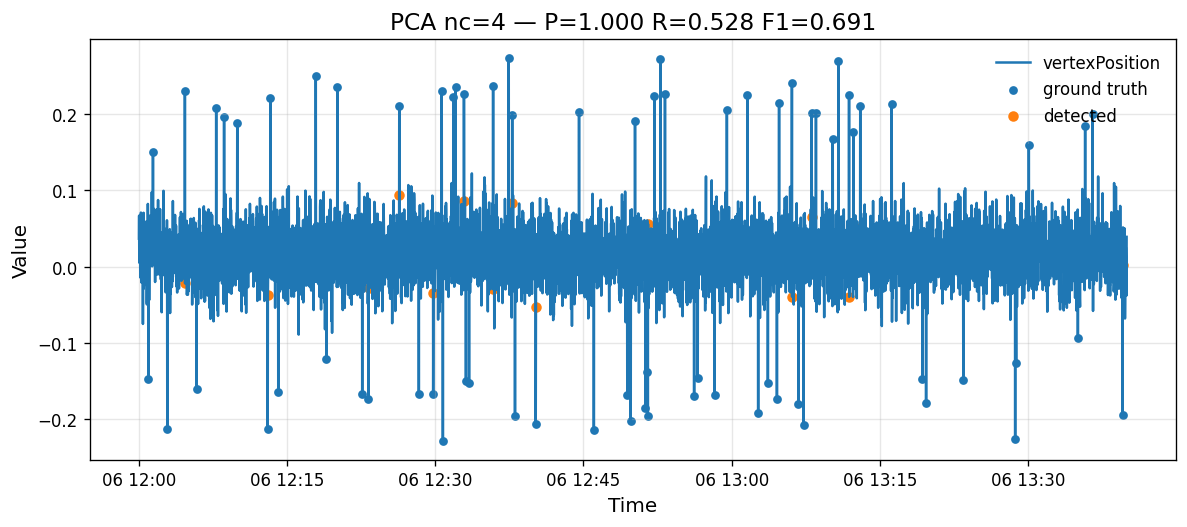

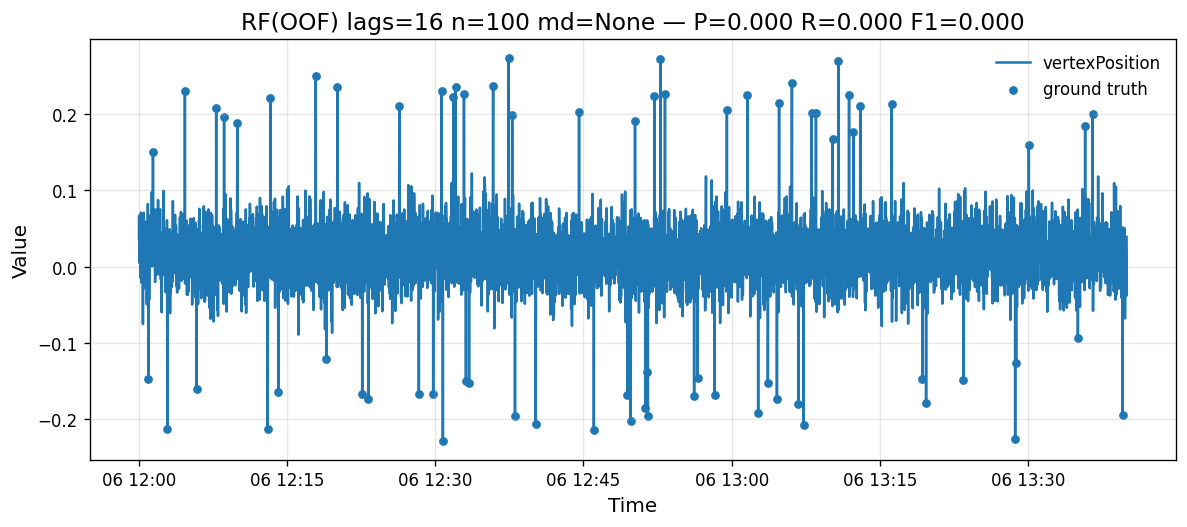

In [34]:
# === Last cell with progress bars for progress reporting ===
from tqdm.auto import tqdm

# ===== Scenario knobs =====
N           = 6000
SPIKE_FRAC  = 0.012
SPIKE_AMP   = 6.0
MIN_SEP     = 6
TOL         = 2  # event matching tolerance

# ===== Generate synthetic spike-only =====
syn, truth = make_spike_only(n=N, spike_frac=SPIKE_FRAC, spike_amp=SPIKE_AMP, min_sep=MIN_SEP, seed=42)
series = syn["vertexPosition"]

# ===== Grid-search per family (with progress bars) =====
stats_res = []
unsup_res = []
sup_res   = []

# --- Statistical grid ---
z_grid   = [3.0, 4.0, 5.0, 6.0, 7.0]
h_k_grid = [3.0, 4.0, 5.0, 6.0]
h_w_grid = [31, 41, 61]
total_stats = len(z_grid) + len(h_k_grid)*len(h_w_grid)

with tqdm(total=total_stats, desc="Statistical grid", leave=True) as pbar:
    # Robust-Z
    for z_thr in z_grid:
        t0=perf_counter(); flags = detect_robustZ(series, z_thr=z_thr); pred_t=perf_counter()-t0
        m = event_prf(flags, truth, tolerance=TOL)
        stats_res.append(dict(method=f"RobustZ|z|>={z_thr}", category="statistical",
                              precision=m["precision"], recall=m["recall"], f1=m["f1"],
                              fit_time=0.0, pred_time=pred_t, train_frac=0.0))
        pbar.update(1)
    # Hampel
    for k in h_k_grid:
        for W in h_w_grid:
            t0=perf_counter(); flags = detect_hampel(series, k=k, window=W); pred_t=perf_counter()-t0
            m = event_prf(flags, truth, tolerance=TOL)
            stats_res.append(dict(method=f"Hampel k={k} W={W}", category="statistical",
                                  precision=m["precision"], recall=m["recall"], f1=m["f1"],
                                  fit_time=0.0, pred_time=pred_t, train_frac=0.0))
            pbar.update(1)

# --- Unsupervised grid ---
if SKLEARN:
    pca_nc_grid = [2,3,4,5]
    if_cont_grid = [0.005, 0.01, 0.02]
    oc_nu_grid   = [0.005, 0.01, 0.02]
    lof_k_grid   = [25, 35, 55]
    total_uns = len(pca_nc_grid) + len(if_cont_grid) + len(oc_nu_grid) + len(lof_k_grid)

    with tqdm(total=total_uns, desc="Unsupervised grid", leave=True) as pbar:
        # PCA (quantile @ 99.5%)
        for nc in pca_nc_grid:
            t0=perf_counter(); score, train_idx = score_pca(syn, n_components=nc, train_frac=0.3); fit_t=perf_counter()-t0
            flags, _ = threshold_by_quantile(score, train_idx, q=0.995)
            m = event_prf(flags, truth.reindex(flags.index), tolerance=TOL)
            unsup_res.append(dict(method=f"PCA nc={nc}", category="unsupervised",
                                  precision=m["precision"], recall=m["recall"], f1=m["f1"],
                                  fit_time=fit_t, pred_time=0.0, train_frac=len(train_idx)/len(score)))
            pbar.update(1)

        # Isolation Forest (quantile @ 99.5%)
        for cont in if_cont_grid:
            t0=perf_counter(); score, train_idx = score_iforest(syn, contamination=cont, train_frac=0.3); fit_t=perf_counter()-t0
            flags, _ = threshold_by_quantile(score, train_idx, q=0.995)
            m = event_prf(flags, truth.reindex(flags.index), tolerance=TOL)
            unsup_res.append(dict(method=f"IForest c={cont}", category="unsupervised",
                                  precision=m["precision"], recall=m["recall"], f1=m["f1"],
                                  fit_time=fit_t, pred_time=0.0, train_frac=len(train_idx)/len(score)))
            pbar.update(1)

        # OC-SVM **decision boundary** (no quantile; flags = score > 0 since score = -decision)
        for nu in oc_nu_grid:
            t0=perf_counter(); score, train_idx = score_ocsvm(syn, nu=nu, gamma="scale", train_frac=0.3, mode="decision"); fit_t=perf_counter()-t0
            flags = (score > 0)  # decision boundary
            m = event_prf(flags, truth.reindex(flags.index), tolerance=TOL)
            unsup_res.append(dict(method=f"OCSVM(dec) nu={nu}", category="unsupervised",
                                  precision=m["precision"], recall=m["recall"], f1=m["f1"],
                                  fit_time=fit_t, pred_time=0.0, train_frac=len(train_idx)/len(score)))
            pbar.update(1)

        # LOF (quantile @ 99.5%)
        for nn in lof_k_grid:
            t0=perf_counter(); score, train_idx = score_lof(syn, n_neighbors=nn, train_frac=0.3); fit_t=perf_counter()-t0
            flags, _ = threshold_by_quantile(score, train_idx, q=0.995)
            m = event_prf(flags, truth.reindex(flags.index), tolerance=TOL)
            unsup_res.append(dict(method=f"LOF k={nn}", category="unsupervised",
                                  precision=m["precision"], recall=m["recall"], f1=m["f1"],
                                  fit_time=fit_t, pred_time=0.0, train_frac=len(train_idx)/len(score)))
            pbar.update(1)

# super
if SKLEARN:
    lags_grid = [6, 10, 16]
    n_grid    = [100, 200, 400]
    md_grid   = [None, 8, 16]
    total_sup = len(lags_grid) * len(n_grid) * len(md_grid)

    with tqdm(total=total_sup, desc="Supervised grid (RF)", leave=True) as pbar:
        for lags in lags_grid:
            for n_est in n_grid:
                for md in md_grid:
                    flags, meta = supervised_rf(
                        syn, truth, lags=lags, n_estimators=n_est, max_depth=md,
                        class_weight="balanced", train_frac=0.5, val_frac=0.2
                    )
                    m = event_prf(flags, truth, tolerance=TOL)
                    sup_res.append(dict(method=f"RF lags={lags} n={n_est} md={md}", category="supervised",
                                        precision=m["precision"], recall=m["recall"], f1=m["f1"],
                                        fit_time=meta.get("fit_time",0.0), pred_time=meta.get("pred_time",0.0),
                                        train_frac=meta.get("train_frac",0.0)))
                    pbar.update(1)

# ===== Results table =====
results_df = pd.DataFrame(stats_res + unsup_res + sup_res)
results_df = results_df.sort_values("f1", ascending=False).reset_index(drop=True)
display(results_df.head(12))

# ===== Pick best per category =====
best_stat = results_df[results_df["category"]=="statistical"].iloc[0]
best_uns  = results_df[results_df["category"]=="unsupervised"].iloc[0] if (results_df["category"]=="unsupervised").any() else None
best_sup  = results_df[results_df["category"]=="supervised"].iloc[0] if (results_df["category"]=="supervised").any() else None

print("Best per category:")
print("  Statistical :", dict(best_stat))
if best_uns is not None: print("  Unsupervised:", dict(best_uns))
if best_sup is not None: print("  Supervised  :", dict(best_sup))

# ===== Publication-quality comparisons =====
# 1) F1 by method (top 12)
barplot(results_df["f1"].head(12), results_df["method"].head(12), "Top-12 methods by F1 (event-based)", "F1")

# 2) Precision and Recall bar charts (top 6 by F1)
top6 = results_df.head(6)
barplot(top6["precision"], top6["method"], "Precision (top-6 by F1)", "Precision")
barplot(top6["recall"], top6["method"], "Recall (top-6 by F1)", "Recall")

# 3) F1 vs Prediction time (bubble size ~ train fraction)
scatter_perf(results_df["pred_time"], results_df["f1"], results_df["method"],
             "F1 vs prediction time", "Prediction time [s]", "F1",
             sizes=100*(results_df["train_frac"]+0.05))

# 4) F1 vs Fit time
scatter_perf(results_df["fit_time"], results_df["f1"], results_df["method"],
             "F1 vs fit time", "Fit time [s]", "F1")

# ===== Visualize best-per-category detections (with a small progress bar) =====
def run_from_label(label):
    if label.startswith("RobustZ"):
        thr = float(label.split(">=")[1])
        return detect_robustZ(series, z_thr=thr)
    if label.startswith("Hampel"):
        parts = label.replace("Hampel ","").split()
        k = float(parts[0].split("=")[1])
        W = int(parts[1].split("=")[1])
        return detect_hampel(series, k=k, window=W)
    if label.startswith("PCA"):
        nc = int(label.split("nc=")[1])
        score, tr = score_pca(syn, n_components=nc, train_frac=0.3)
        flags, _ = threshold_by_quantile(score, tr, q=0.995)
        return flags.reindex(series.index, fill_value=False)
    if label.startswith("IForest"):
        c = float(label.split("c=")[1])
        score, tr = score_iforest(syn, contamination=c, train_frac=0.3)
        flags, _ = threshold_by_quantile(score, tr, q=0.995)
        return flags.reindex(series.index, fill_value=False)
    if label.startswith("OCSVM"):
        nu = float(label.split("nu=")[1])
        score, tr = score_ocsvm(syn, nu=nu, gamma="scale", train_frac=0.3)
        flags, _ = threshold_by_quantile(score, tr, q=0.995)
        return flags.reindex(series.index, fill_value=False)
    if label.startswith("LOF"):
        k = int(label.split("k=")[1])
        score, tr = score_lof(syn, n_neighbors=k, train_frac=0.3)
        flags, _ = threshold_by_quantile(score, tr, q=0.995)
        return flags.reindex(series.index, fill_value=False)
    if label.startswith("RF "):
        parts = label.split()
        lags = int(parts[1].split("=")[1]); n = int(parts[2].split("=")[1]); md = parts[3].split("=")[1]
        md = None if md=="None" else int(md)
        flags, _ = supervised_rf(syn, truth, lags=lags, n_estimators=n, max_depth=md)
        return flags
    return pd.Series(False, index=series.index)

chosen = [best_stat["method"]]
if best_uns is not None: chosen.append(best_uns["method"])
if best_sup is not None: chosen.append(best_sup["method"])

with tqdm(total=len(chosen), desc="Plot chosen methods", leave=True) as pbar:
    for label in chosen:
        flags = run_from_label(label)
        m = event_prf(flags, truth, tolerance=TOL)
        plot_series_with_truth_and_flags(series.rename("vertexPosition"), truth, flags,
                                         f"{label} — P={m['precision']:.3f} R={m['recall']:.3f} F1={m['f1']:.3f}")
        pbar.update(1)

In [45]:
import os
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from time import perf_counter

plt.rcParams.update({
    "figure.dpi": 140,
    "savefig.dpi": 300,
    "axes.titlesize": 16,
    "axes.labelsize": 13,
    "axes.grid": True,
    "grid.alpha": 0.25,
    "legend.frameon": False,
    "xtick.labelsize": 11,
    "ytick.labelsize": 11,
})

def _ensure_outdir(outdir="figs"):
    os.makedirs(outdir, exist_ok=True)
    return outdir

def _savefig(path):
    plt.tight_layout()
    plt.savefig(path, bbox_inches="tight")
    plt.show()
    print(f"saved: {path}")

def _as_df(X, like_df):
    """Ensure X is a DataFrame with the same columns as like_df."""
    if isinstance(X, pd.DataFrame):
        return X.loc[:, list(like_df.columns)]
    return pd.DataFrame(np.asarray(X), index=getattr(like_df, "index", None), columns=list(like_df.columns))

def mad(x):
    x = np.asarray(x)
    m = np.median(x)
    return np.median(np.abs(x - m))

def robust_z(x):
    x = pd.Series(x)
    m = x.median()
    M = mad(x)
    if M == 0:
        s = x.std(ddof=1)
        return (x - x.mean()) / (s if s>0 else 1.0)
    return 0.67448975 * (x - m) / M

def event_prf(flags: pd.Series, truth: pd.Series, tolerance=2):
    """Event-based PRF: TP if a detected index is within ±tolerance of a truth spike."""
    flags = flags.reindex(truth.index).fillna(False)
    f_idx = np.where(flags.values)[0].tolist()
    t_idx = np.where(truth.values)[0].tolist()
    tp = 0; used_truth=set()
    for i in f_idx:
        candidates = [j for j in t_idx if abs(j-i) <= tolerance and j not in used_truth]
        if candidates:
            j = min(candidates, key=lambda j: abs(j-i))
            used_truth.add(j); tp += 1
    fp = len(f_idx) - tp
    fn = len(t_idx) - tp
    P = tp/(tp+fp) if (tp+fp)>0 else 0.0
    R = tp/(tp+fn) if (tp+fn)>0 else 0.0
    F1 = 2*P*R/(P+R) if (P+R)>0 else 0.0
    return dict(tp=tp, fp=fp, fn=fn, precision=P, recall=R, f1=F1)

def plot_series_with_truth_and_flags(ts: pd.Series, truth: pd.Series, flags: pd.Series, title=""):
    ts = ts.sort_index()
    truth = truth.reindex(ts.index).fillna(False)
    flags = flags.reindex(ts.index).fillna(False)
    plt.figure()
    plt.plot(ts.index, ts.values, label=ts.name or "series")
    if truth.any():
        plt.scatter(ts.index[truth], ts.values[truth], s=18, label="ground truth")
    if flags.any():
        plt.scatter(ts.index[flags], ts.values[flags], s=28, label="detected")
    plt.title(title); plt.xlabel("Time"); plt.ylabel("Value"); plt.legend(); plt.tight_layout(); plt.show()

def make_windowed_ml_features(df: pd.DataFrame, truth: pd.Series, lags=10):
    X = pd.DataFrame(index=df.index)
    X["vertex"] = df["vertexPosition"]
    X["deltaT"] = df["deltaT"]; X["sumT"] = df["sumT"]
    for L in range(1, lags+1):
        X[f"vertex_lag{L}"] = df["vertexPosition"].shift(L)
        X[f"deltaT_lag{L}"] = df["deltaT"].shift(L)
        X[f"sumT_lag{L}"]   = df["sumT"].shift(L)
    X = X.dropna()
    y = truth.reindex(X.index).fillna(False)
    return X, y

In [38]:
from sklearn.ensemble import RandomForestClassifier
from sklearn.inspection import permutation_importance, PartialDependenceDisplay
from time import perf_counter
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd

def rf_train_val_test_explained(df: pd.DataFrame, truth: pd.Series,
                                lags=12, n_estimators=300, max_depth=None,
                                class_weight="balanced",
                                train_frac=0.6, val_frac=0.2, tolerance=2, seed=42):
    """
    Chronological split [train | val | test], grade on TEST only.
    Uses DataFrames consistently (fit/predict/explain) to avoid feature-name warnings.
    """
    # --- windowed features (DataFrame) ---
    X, y = make_windowed_ml_features(df, truth, lags=lags)
    n = len(X)
    n_train = max(200, int(train_frac*n))
    n_val   = max(100, int(val_frac*n))
    n_test  = n - n_train - n_val
    if n_test <= 0:
        raise ValueError("Not enough samples for test after splitting. Adjust train/val fractions or lengthen data.")

    Xtr, ytr = X.iloc[:n_train], y.iloc[:n_train]
    Xva, yva = X.iloc[n_train:n_train+n_val], y.iloc[n_train:n_train+n_val]
    Xte, yte = X.iloc[n_train+n_val:],        y.iloc[n_train+n_val:]
    series   = df["vertexPosition"].reindex(X.index)

    if yte.sum() == 0:
        print("⚠️ No spikes in TEST window — recall will be 0 by definition.")

    # --- fit with DataFrame (keeps feature names) ---
    RF = RandomForestClassifier(
        n_estimators=n_estimators, max_depth=max_depth,
        class_weight=class_weight, random_state=seed, n_jobs=-1
    )
    t0 = perf_counter(); RF.fit(Xtr, ytr); fit_t = perf_counter()-t0

    # --- choose threshold on VALIDATION by max event-F1 ---
    proba_va = RF.predict_proba(Xva)[:, 1]
    thr_grid = np.linspace(0.05, 0.95, 37)
    best_thr, best_f1 = 0.5, -1
    for th in thr_grid:
        flags_va = pd.Series(proba_va >= th, index=Xva.index)
        f = event_prf(flags_va, truth.reindex(flags_va.index), tolerance=tolerance)["f1"]
        if f > best_f1:
            best_f1, best_thr = f, th

    # --- predict TEST with DataFrame ---
    t1 = perf_counter(); proba_te = RF.predict_proba(Xte)[:, 1]; pred_t = perf_counter()-t1
    flags_te = pd.Series(proba_te >= best_thr, index=Xte.index, name="RF_flags_test")

    metrics_test = event_prf(flags_te, truth.reindex(flags_te.index), tolerance=tolerance)
    print(f"RF test-only (lags={lags}, n={n_estimators}, md={max_depth}, thr={best_thr:.3f}) "
          f"=> P={metrics_test['precision']:.3f} R={metrics_test['recall']:.3f} F1={metrics_test['f1']:.3f} "
          f"| fit={fit_t:.3f}s pred={pred_t:.3f}s train_frac={n_train/n:.2f}")

    # --- detections on TEST ---
    plot_series_with_truth_and_flags(
        series.reindex(flags_te.index).rename("vertexPosition"),
        truth.reindex(flags_te.index), flags_te,
        f"RF Test — detections (P={metrics_test['precision']:.3f} R={metrics_test['recall']:.3f} F1={metrics_test['f1']:.3f})"
    )

    # --- probability trace + threshold ---
    plt.figure(figsize=(10,3.5))
    plt.plot(flags_te.index, proba_te, label="RF P(anomaly)")
    plt.axhline(best_thr, linestyle="--", label="threshold")
    if flags_te.any():
        plt.scatter(flags_te.index[flags_te], proba_te[flags_te.values], s=26, label="detected")
    plt.title("RF probability (test)"); plt.xlabel("Time"); plt.ylabel("Probability")
    plt.legend(); plt.tight_layout(); plt.show()

    # --- feature importances (Gini) ---
    imp = pd.Series(RF.feature_importances_, index=X.columns, name="importance").sort_values(ascending=False)
    topk = 12
    plt.figure(figsize=(8,5))
    plt.barh(imp.index[:topk][::-1], imp.values[:topk][::-1])
    plt.title("RandomForest feature importances (top)"); plt.xlabel("Importance")
    plt.tight_layout(); plt.show()

    # --- permutation importance ON TEST (uses DataFrame; no warning) ---
    perm = permutation_importance(RF, Xte, yte, n_repeats=5, random_state=seed, n_jobs=-1)
    perm_imp = pd.Series(perm.importances_mean, index=X.columns, name="perm_importance").sort_values(ascending=False)
    plt.figure(figsize=(8,5))
    plt.barh(perm_imp.index[:topk][::-1], perm_imp.values[:topk][::-1])
    plt.title("Permutation importance on TEST (top)"); plt.xlabel("Score drop")
    plt.tight_layout(); plt.show()

    # --- partial dependence for top features (DataFrame; no warning) ---
    try:
        top_features = list(imp.index[:2])
        if top_features:
            fig, ax = plt.subplots(1, len(top_features), figsize=(10, 3.8), constrained_layout=True)
            if len(top_features) == 1: ax = [ax]
            PartialDependenceDisplay.from_estimator(RF, Xtr, top_features, ax=ax)  # Xtr is a DataFrame
            for a, f in zip(ax, top_features): a.set_title(f"PDP: {f}")
            plt.show()
    except Exception as e:
        print("PDP skipped:", e)

    return {
        "rf": RF, "threshold": best_thr,
        "train_idx": Xtr.index, "val_idx": Xva.index, "test_idx": Xte.index,
        "flags_test": flags_te, "proba_test": pd.Series(proba_te, index=Xte.index),
        "importances": imp, "perm_importances": perm_imp,
        "metrics_test": metrics_test,
        "fit_time": fit_t, "pred_time": pred_t, "train_frac": n_train/n,
        "feature_names": X.columns.tolist()
    }

RF test-only (lags=16, n=300, md=16, thr=0.075) => P=1.000 R=0.875 F1=0.933 | fit=1.486s pred=0.194s train_frac=0.60


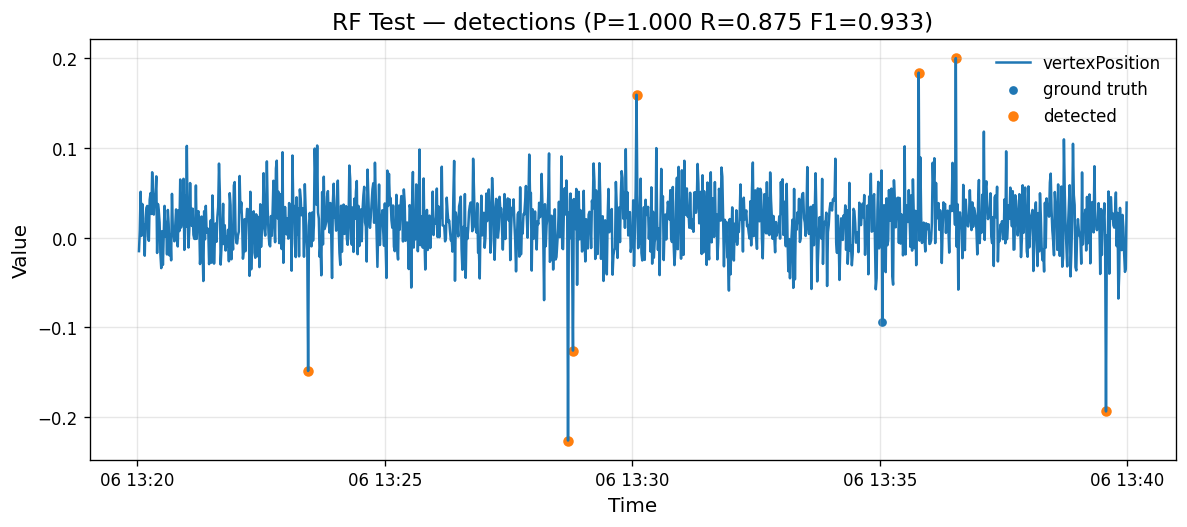

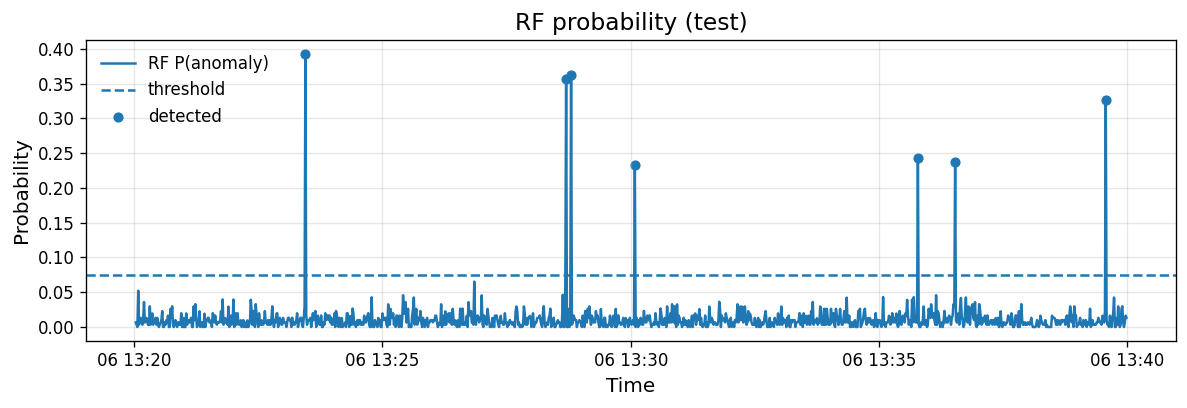

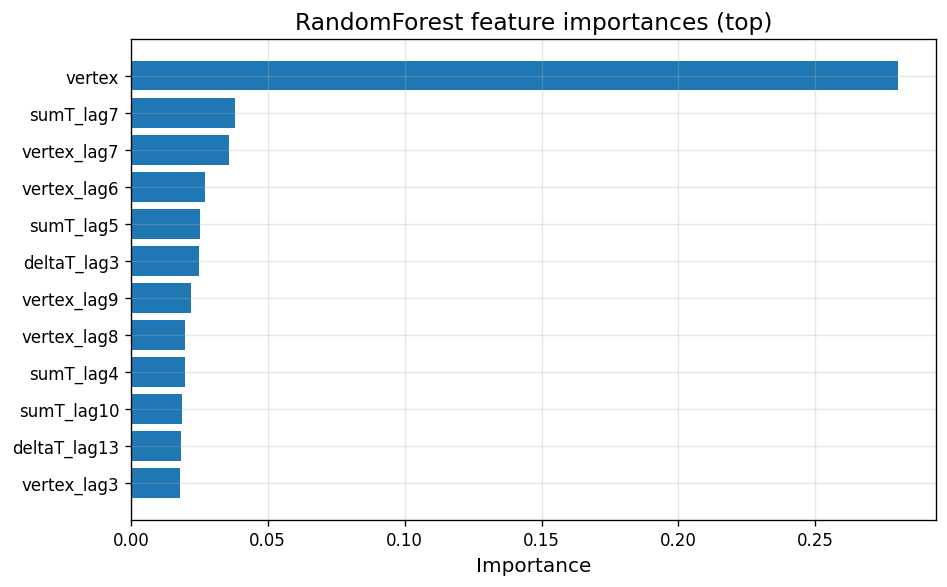

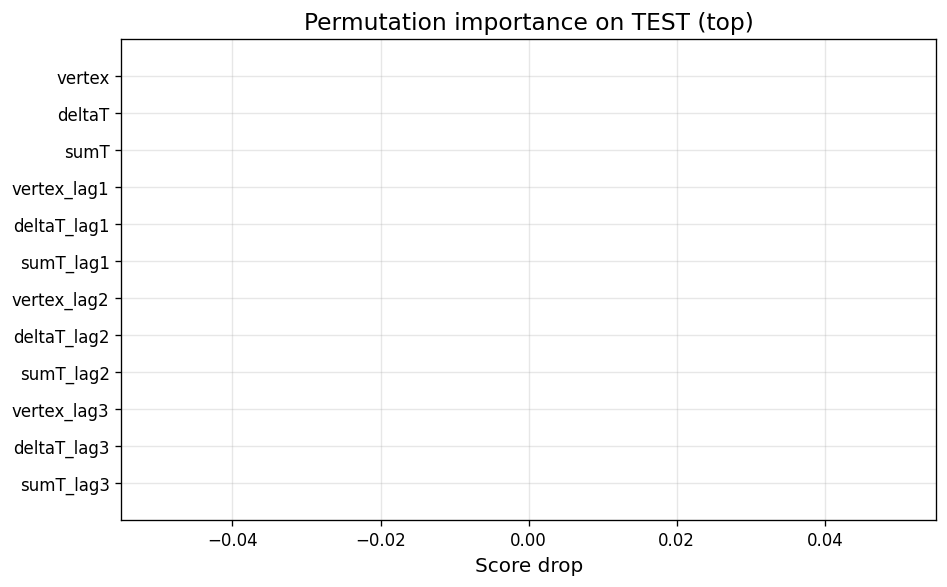

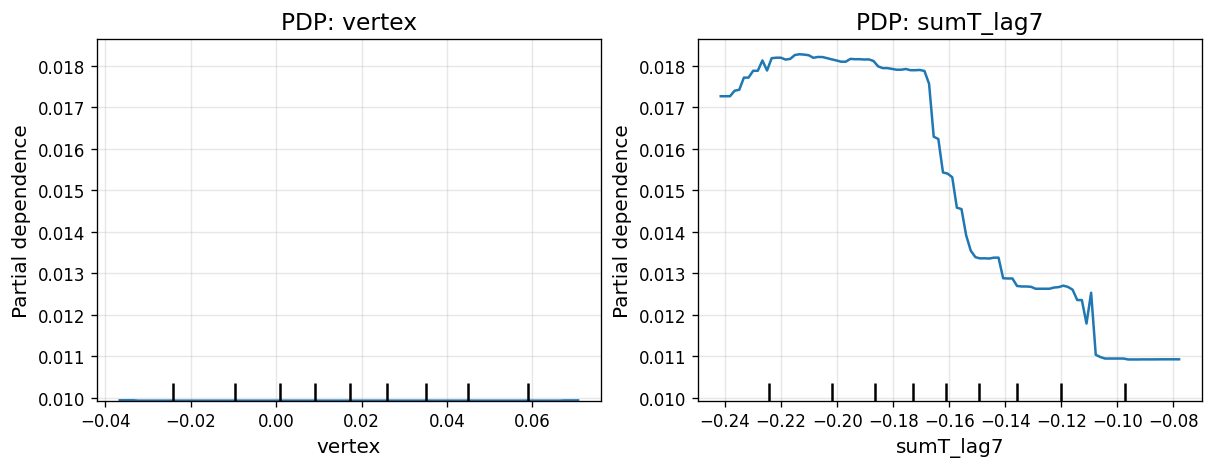

In [39]:
# If you already have 'syn' (with columns timeA,timeC,vertexPosition,deltaT,sumT) and 'truth' (is_spike),
# just run this:
res = rf_train_val_test_explained(
    df=syn, truth=truth,
    lags=16, n_estimators=300, max_depth=16,
    class_weight="balanced", train_frac=0.6, val_frac=0.2, tolerance=2, seed=42
)

In [52]:
from sklearn.preprocessing import StandardScaler
from sklearn.svm import OneClassSVM
import matplotlib.lines as mlines

def _unsup_feats(df: pd.DataFrame, window=41) -> pd.DataFrame:
    v = df["vertexPosition"]
    zloc, _, _ = _local_robust_z(v, window=window)
    feats = pd.DataFrame({
        "z_local": zloc,
        "d_vertex_abs": v.diff().abs(),
        "abs_deltaT": df["deltaT"].abs(),
        "abs_sumT": df["sumT"].abs(),
    }, index=df.index)
    return feats.dropna()

def _local_robust_z(series: pd.Series, window=41):
    W = int(window) if int(window)%2==1 else int(window)+1
    med = series.rolling(W, center=True).median()
    mad = series.rolling(W, center=True).apply(lambda x: np.median(np.abs(x - np.median(x))), raw=False)
    zloc = (series - med) / (1.4826*mad + 1e-12)
    return zloc, med, mad

def _unsup_feats_min(df: pd.DataFrame, window=41) -> pd.DataFrame:
    """Minimal, high-signal features to reduce false positives."""
    v = df["vertexPosition"]
    zloc, _, _ = _local_robust_z(v, window=window)
    feats = pd.DataFrame({
        "z_local": zloc,              # local standardized deviation of vertex
        "d_vertex_abs": v.diff().abs()# spike slope
    }, index=df.index)
    return feats.dropna()

def ocsvm_precision_tuned_explain(
    df: pd.DataFrame, truth: pd.Series,
    rf_split=None,                 # dict with 'train_idx','val_idx','test_idx' (optional)
    window=41,
    nu_grid=(0.002, 0.005, 0.01),  # lower nu => tighter boundary => fewer FPs
    gamma_grid=("scale","auto", 0.1, 0.2, 0.5, 1.0),
    margin_grid=(0.0, 0.25, 0.5, 1.0, 1.5, 2.0),  # margin in TRAIN-STD units on (-decision)
    train_frac=0.3,
    tolerance=2,
    purify_q=0.99,                 # drop top 1% extremes in train (unsupervised purification)
    outdir="figs", tag="case", seed=42,
    optimize="f1"                  # or "precision" if you want maximum precision on VAL
):
    """
    Unsupervised OCSVM (RBF) on {z_local, |Δv|}, with:
      - robust scaling,
      - self-purified training (drop extreme z_local / |Δv| in TRAIN by quantile),
      - validation-tuned hyperparams (nu, gamma) AND score margin τ on (-decision/σ_train).
    We grade on TEST only and save three PNGs (detections, boundary, score).
    """
    rng = np.random.default_rng(seed)
    outdir = _ensure_outdir(outdir)

    # --- features
    feats_all = _unsup_feats_min(df, window=window)
    truth_f = truth.reindex(feats_all.index).fillna(False)

    # --- splits
    if rf_split is not None:
        tr_idx = feats_all.index.intersection(rf_split["train_idx"])
        va_idx = feats_all.index.intersection(rf_split["val_idx"])
        te_idx = feats_all.index.intersection(rf_split["test_idx"])
        if min(len(tr_idx), len(va_idx), len(te_idx)) == 0:
            raise ValueError("OCSVM: RF-aligned indices do not overlap with features; adjust window/splits.")
    else:
        n = len(feats_all)
        n_train = max(200, int(train_frac*n))
        n_val   = max(100, int(0.2*n))
        tr_idx = feats_all.index[:n_train]
        va_idx = feats_all.index[n_train:n_train+n_val]
        te_idx = feats_all.index[n_train+n_val:]

    Xtr0 = feats_all.loc[tr_idx].copy()
    Xva0 = feats_all.loc[va_idx].copy()
    Xte0 = feats_all.loc[te_idx].copy()

    # --- unsupervised "purification" of training (drop extreme points by quantile)
    z_abs = Xtr0["z_local"].abs()
    dv_abs = Xtr0["d_vertex_abs"]
    z_thr = z_abs.quantile(purify_q)
    dv_thr = dv_abs.quantile(purify_q)
    keep = (z_abs <= z_thr) & (dv_abs <= dv_thr)
    Xtr0 = Xtr0.loc[keep]

    # --- scale (DF to keep names)
    scaler = StandardScaler().fit(Xtr0)
    Xtr = pd.DataFrame(scaler.transform(Xtr0), index=Xtr0.index, columns=Xtr0.columns)
    Xva = pd.DataFrame(scaler.transform(Xva0), index=Xva0.index, columns=Xva0.columns)
    Xte = pd.DataFrame(scaler.transform(Xte0), index=Xte0.index, columns=Xte0.columns)

    # === search (nu, gamma, margin τ) on VALIDATION
    best = None
    for nu in nu_grid:
        for gm in gamma_grid:
            oc = OneClassSVM(nu=nu, gamma=gm).fit(Xtr)
            # standardize decision by train STD to make τ meaningful
            dec_tr = oc.decision_function(Xtr).ravel()
            sigma = np.std(dec_tr) if np.std(dec_tr)>1e-9 else 1.0

            dec_va = oc.decision_function(Xva).ravel()
            s_va = (-dec_va) / sigma  # higher => more anomalous

            for tau in margin_grid:
                flags_va = pd.Series(s_va >= tau, index=Xva.index)
                m = event_prf(flags_va, truth_f.reindex(flags_va.index), tolerance=tolerance)
                key = (m["precision"] if optimize=="precision" else m["f1"])
                if (best is None) or (key > best["key"]):
                    best = dict(nu=nu, gamma=gm, tau=tau, sigma=sigma, metrics=m, key=key)

    # === TEST with best
    oc_best = OneClassSVM(nu=best["nu"], gamma=best["gamma"]).fit(Xtr)
    sigma = best["sigma"]
    dec_te = oc_best.decision_function(Xte).ravel()
    s_te = (-dec_te) / sigma
    flags_te = pd.Series(s_te >= best["tau"], index=Xte.index, name="OCSVM_flags_test")
    metrics_test = event_prf(flags_te, truth_f.reindex(flags_te.index), tolerance=tolerance)

    print(f"OCSVM(test) nu={best['nu']}, gamma={best['gamma']}, tau={best['tau']} "
          f"=> P={metrics_test['precision']:.3f} R={metrics_test['recall']:.3f} F1={metrics_test['f1']:.3f} "
          f"[val: P={best['metrics']['precision']:.3f} R={best['metrics']['recall']:.3f} F1={best['metrics']['f1']:.3f}]")

    # === Fig 1: detections (TEST)
    s_test = df["vertexPosition"].reindex(flags_te.index)
    plt.figure(figsize=(11,3.6))
    plt.plot(s_test.index, s_test.values, linewidth=1.2, label="vertexPosition")
    truth_t = truth_f.reindex(flags_te.index)
    if truth_t.any():
        plt.scatter(s_test.index[truth_t], s_test.values[truth_t], s=22, label="ground truth")
    if flags_te.any():
        plt.scatter(s_test.index[flags_te], s_test.values[flags_te], s=30, label="OCSVM detected")
    plt.title(f"OCSVM (TEST) — P={metrics_test['precision']:.3f} R={metrics_test['recall']:.3f} F1={metrics_test['f1']:.3f}")
    plt.xlabel("Time"); plt.ylabel("vertexPosition"); plt.legend(loc="upper left", ncols=3)
    _savefig(os.path.join(outdir, f"ocsvm_prec_detections_{tag}.png"))

    # === Fig 2: boundary in (z_local, |Δv|) plane with margin contour (approx)
    plane = ["z_local","d_vertex_abs"]
    Xtr2 = Xtr[plane]; Xte2 = Xte[plane]
    oc2 = OneClassSVM(nu=best["nu"], gamma=best["gamma"]).fit(Xtr2)
    xs = np.linspace(Xtr2[plane[0]].quantile(0.001), Xtr2[plane[0]].quantile(0.999), 220)
    ys = np.linspace(Xtr2[plane[1]].quantile(0.001), Xtr2[plane[1]].quantile(0.999), 220)
    XX, YY = np.meshgrid(xs, ys)
    grid_df = pd.DataFrame(np.c_[XX.ravel(), YY.ravel()], columns=plane)
    dec_grid = np.asarray(oc2.decision_function(grid_df)).reshape(XX.shape)
    # 0-contour is native boundary; draw an approximate margin contour at -tau*sigma
    level_margin = -best["tau"] * sigma
    plt.figure(figsize=(6.8,5.6))
    plt.scatter(Xtr2[plane[0]], Xtr2[plane[1]], s=8, alpha=0.6, label="train (normal)")
    c = flags_te.astype(int).reindex(Xte2.index).fillna(0).values
    plt.scatter(Xte2[plane[0]], Xte2[plane[1]], s=14, c=c, cmap="coolwarm", alpha=0.85, label="test")
    cs0 = plt.contour(XX, YY, dec_grid, levels=[0], linewidths=2, colors="k")
    cs1 = plt.contour(XX, YY, dec_grid, levels=[level_margin], linestyles="--", linewidths=1.5, colors="k")
    boundary_proxy  = mlines.Line2D([], [], color='k', lw=2, label='decision boundary (0)')
    margin_proxy    = mlines.Line2D([], [], color='k', lw=1.5, ls='--', label=f'margin (τ={best["tau"]})')
    handles, labels = plt.gca().get_legend_handles_labels()
    handles += [boundary_proxy, margin_proxy]; labels += ["decision boundary (0)", f"margin (τ={best['tau']})"]
    plt.legend(handles, labels, loc="best")
    plt.xlabel(plane[0]); plt.ylabel(plane[1]); plt.title("OCSVM boundary with margin (feature space)")
    _savefig(os.path.join(outdir, f"ocsvm_prec_boundary_{tag}.png"))

    # === Fig 3: standardized score trace s_te = (-decision)/σ_train with margin τ
    score_te = pd.Series(s_te, index=Xte.index, name="OCSVM_std_score")
    plt.figure(figsize=(11,3.2))
    plt.plot(score_te.index, score_te.values, linewidth=1.1, label="OCSVM standardized score")
    if flags_te.any():
        plt.scatter(score_te.index[flags_te], score_te.values[flags_te], s=24, label="detected")
    plt.axhline(best["tau"], linestyle="--", linewidth=1.0, label=f"margin τ={best['tau']}")
    plt.title("OCSVM standardized anomaly score (TEST)"); plt.xlabel("Time"); plt.ylabel("Score (std units)")
    plt.legend(loc="upper left", ncols=3)
    _savefig(os.path.join(outdir, f"ocsvm_prec_score_{tag}.png"))

    return {
        "flags_test": flags_te,
        "metrics_test": metrics_test,
        "best_params": dict(nu=best["nu"], gamma=best["gamma"], tau=best["tau"], window=window, purify_q=purify_q),
        "paths": {
            "detections": os.path.join(outdir, f"ocsvm_prec_detections_{tag}.png"),
            "boundary":   os.path.join(outdir, f"ocsvm_prec_boundary_{tag}.png"),
            "score":      os.path.join(outdir, f"ocsvm_prec_score_{tag}.png"),
        }
    }

RF test-only (lags=16, n=300, md=16, thr=0.075) => P=1.000 R=0.875 F1=0.933 | fit=1.535s pred=0.227s train_frac=0.60


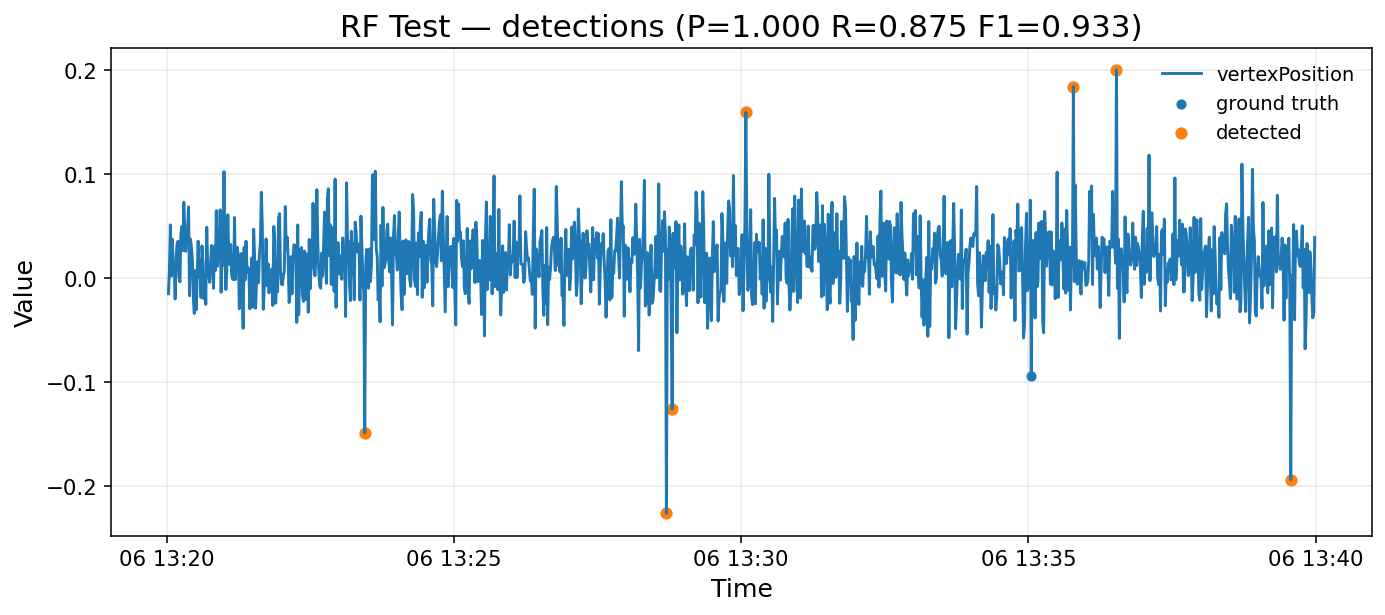

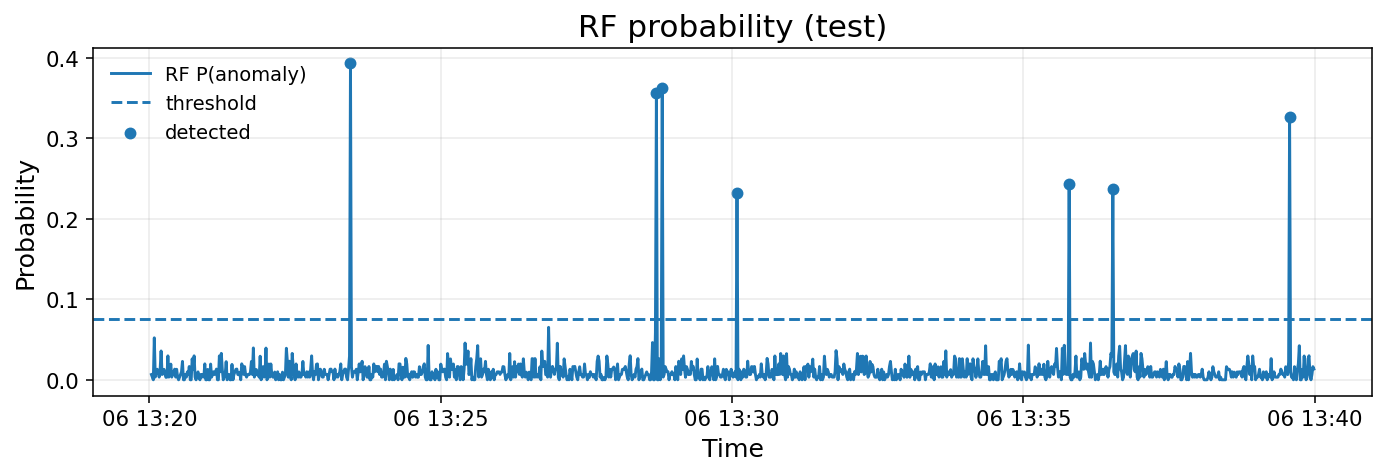

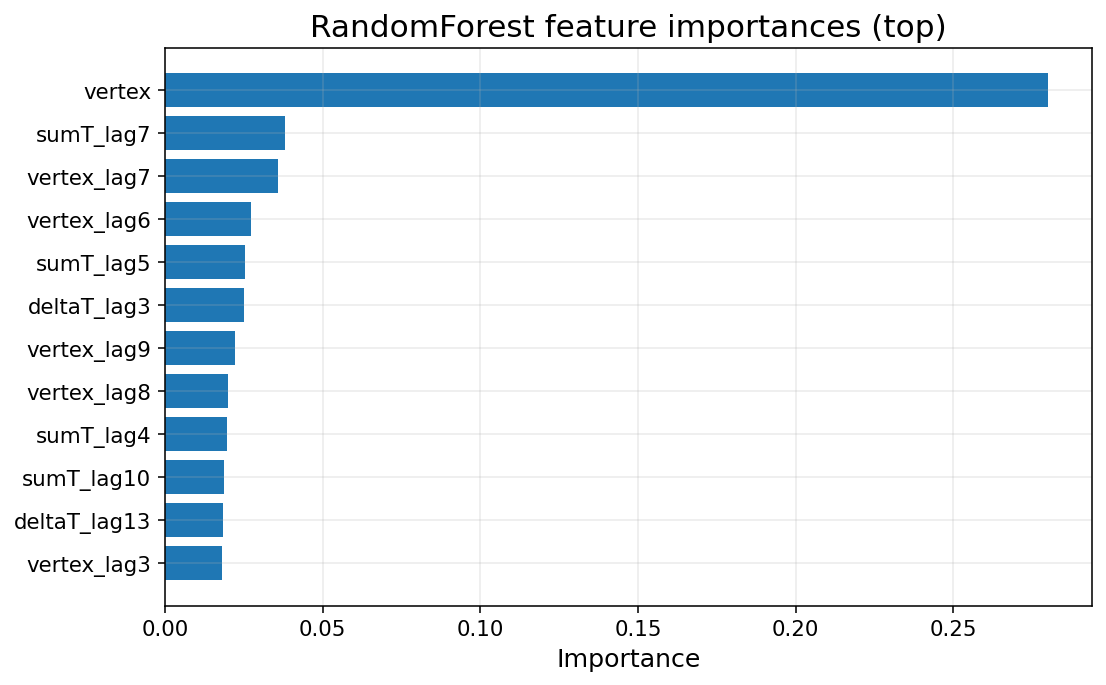

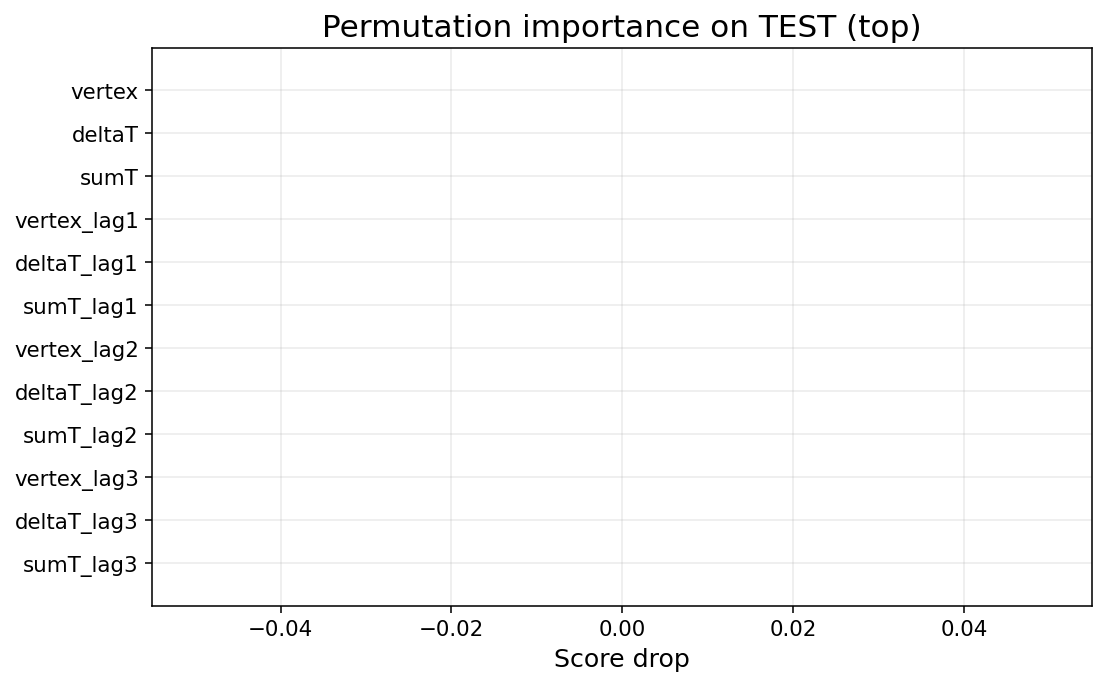

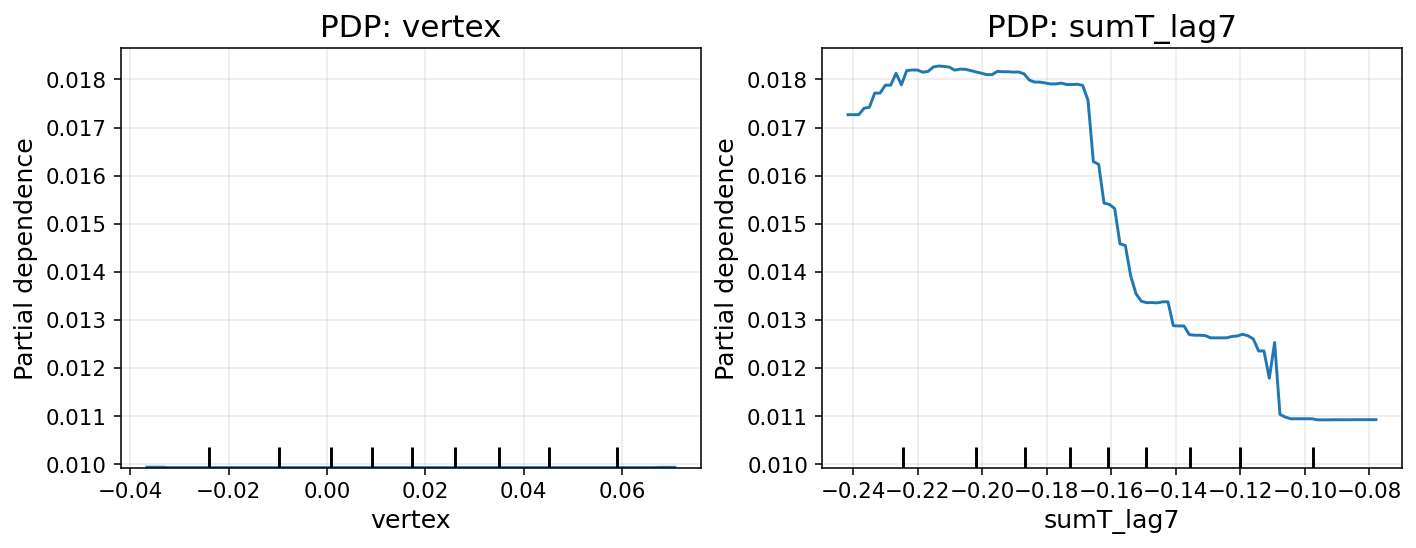

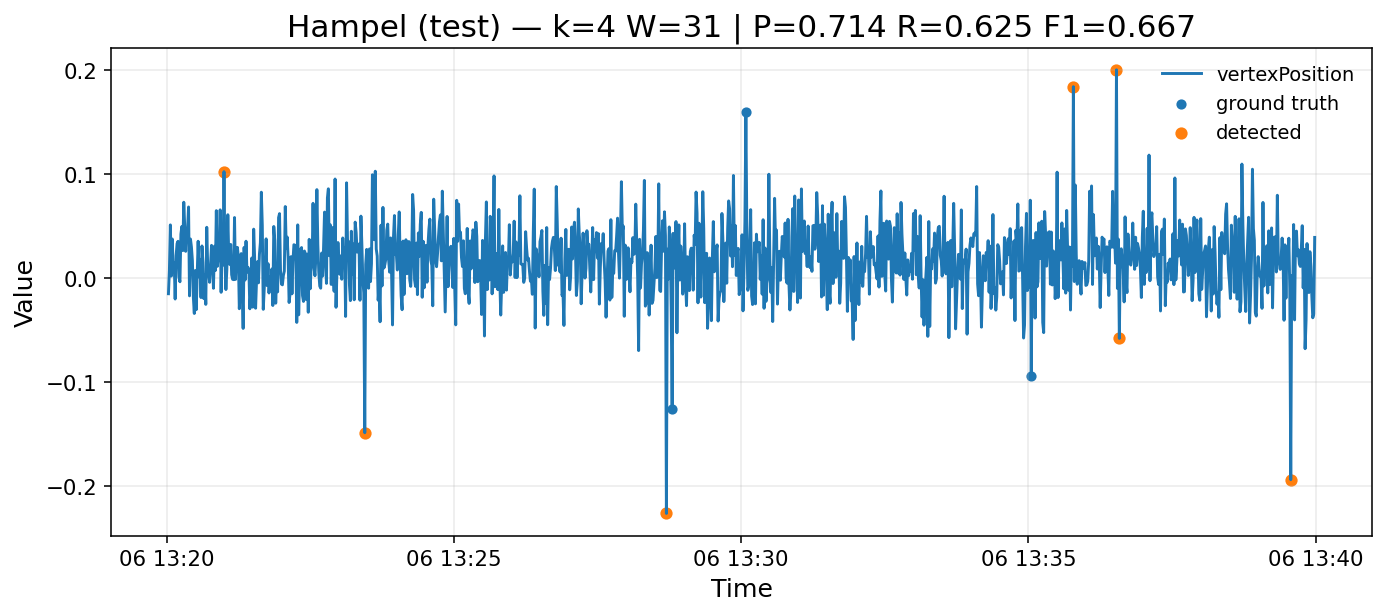

OCSVM test-only (nu=0.02, gamma=scale) => P=0.185 R=0.625 F1=0.286 [best val F1=0.429]


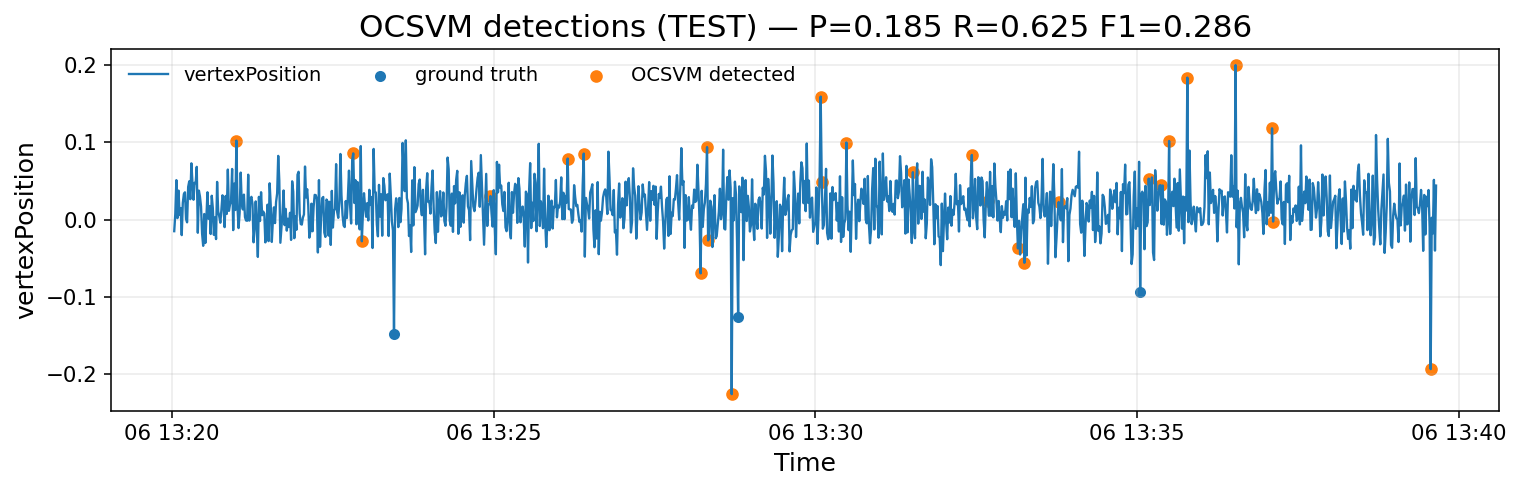

saved: figs/ocsvm_detections_case.png


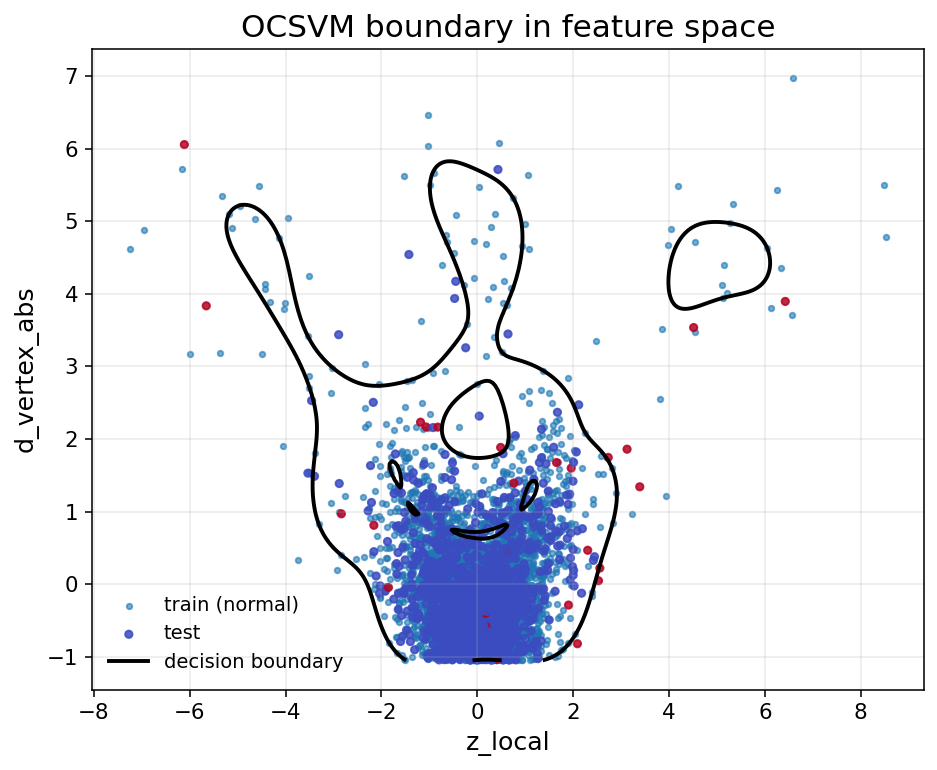

saved: figs/ocsvm_boundary_case.png


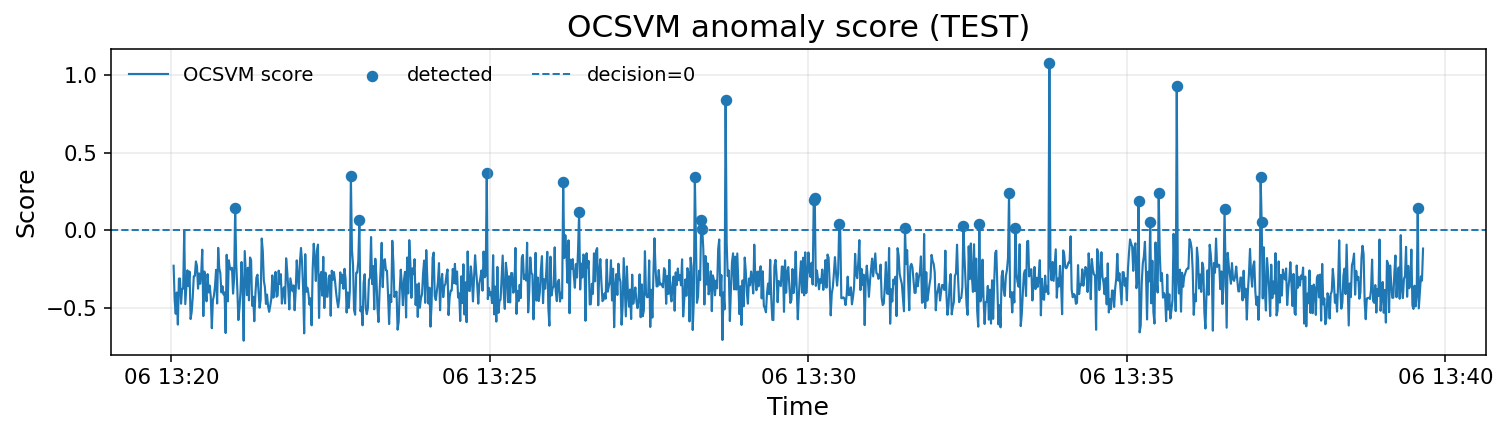

saved: figs/ocsvm_score_case.png


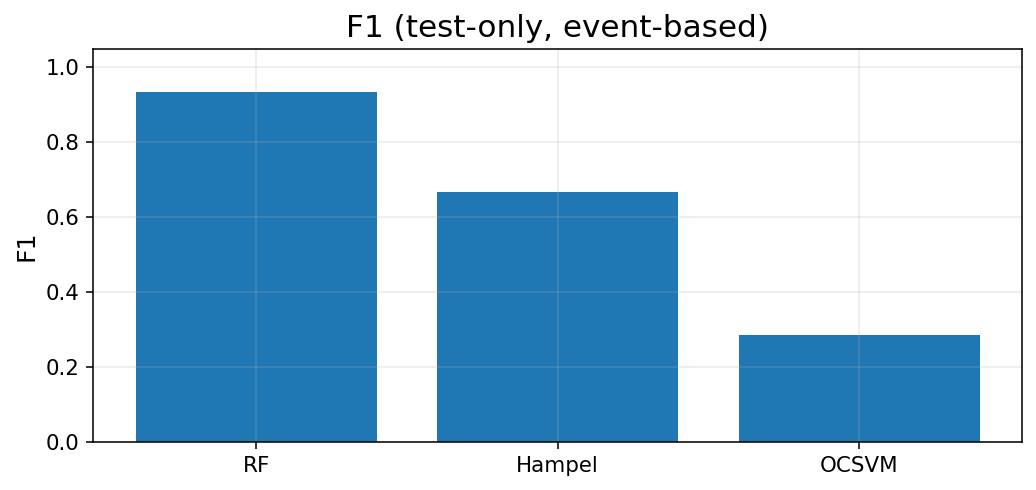

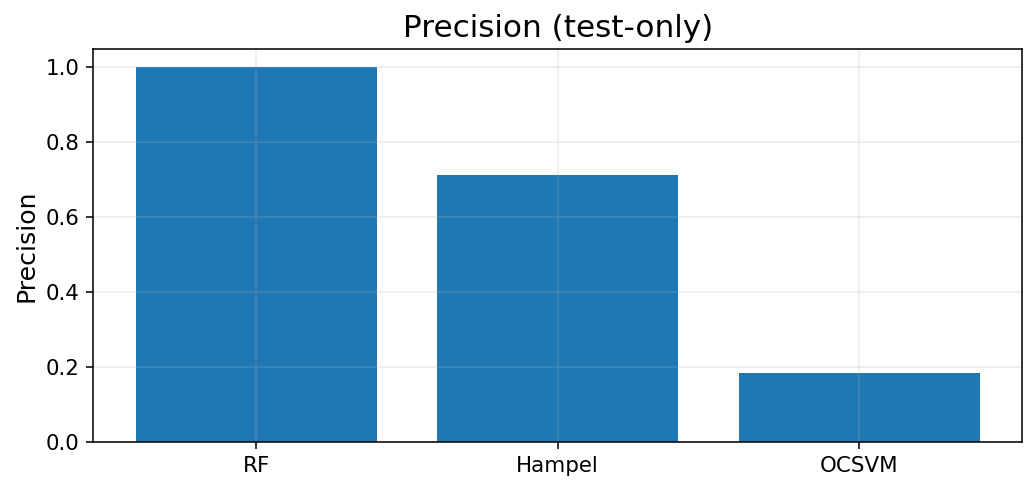

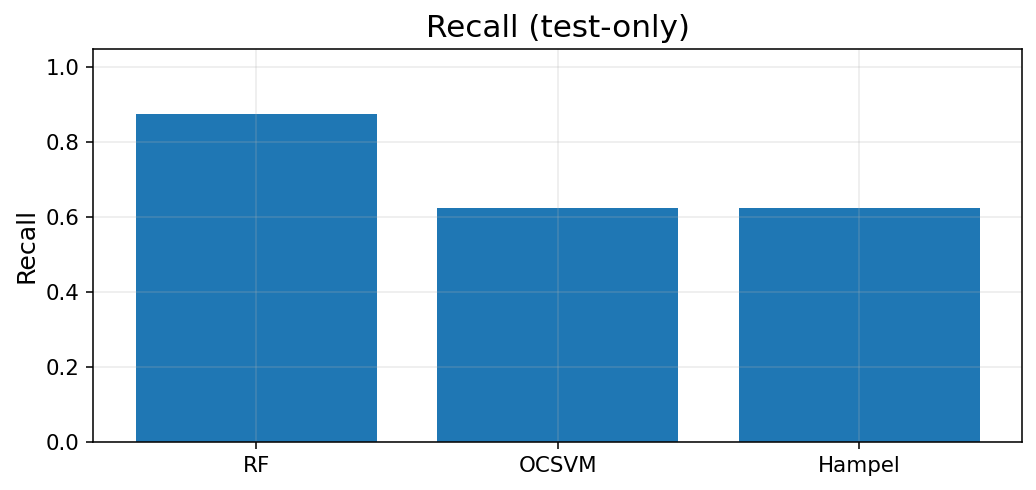

In [49]:
# === Generate (or reuse) spike-only synthetic ===
try:
    syn, truth   # reuse if present
except NameError:
    syn, truth = make_spike_only(n=6000, spike_frac=0.012, spike_amp=6.0, min_sep=6, seed=42)

# === Supervised RF (test-only grading, already explained) ===
rf_res = rf_train_val_test_explained(
    df=syn, truth=truth,
    lags=16, n_estimators=300, max_depth=16,
    class_weight="balanced", train_frac=0.6, val_frac=0.2, tolerance=2, seed=42
)

# === Statistical (Hampel), tuned by validation; graded on TEST only ===
def hampel_tuned_test(series: pd.Series, truth: pd.Series, val_idx, test_idx, k_grid=(3,4,5,6), W_grid=(31,41,61), tol=2):
    best=None
    for k in k_grid:
        for W in W_grid:
            med = series.rolling(W, center=True).median()
            madw= series.rolling(W, center=True).apply(lambda x: np.median(np.abs(x - np.median(x))), raw=False)
            band= 1.4826*madw*k
            flags_all = ((series > med + band) | (series < med - band)).fillna(False)
            flags_val = flags_all.reindex(val_idx)
            m = event_prf(flags_val, truth.reindex(val_idx), tolerance=tol)
            if (best is None) or (m["f1"] > best["f1"]):
                best = dict(k=k, W=W, f1=m["f1"])
    # test with best
    k, W = best["k"], best["W"]
    med = series.rolling(W, center=True).median()
    madw= series.rolling(W, center=True).apply(lambda x: np.median(np.abs(x - np.median(x))), raw=False)
    band= 1.4826*madw*k
    flags_all = ((series > med + band) | (series < med - band)).fillna(False)
    flags_test = flags_all.reindex(test_idx)
    m_test = event_prf(flags_test, truth.reindex(test_idx), tolerance=tol)
    return flags_test, m_test, best

h_flags, h_metrics, h_best = hampel_tuned_test(
    syn["vertexPosition"], truth,
    val_idx=rf_res["val_idx"], test_idx=rf_res["test_idx"], tol=2
)
plot_series_with_truth_and_flags(
    syn["vertexPosition"].reindex(rf_res["test_idx"]).rename("vertexPosition"),
    truth.reindex(rf_res["test_idx"]), h_flags,
    f"Hampel (test) — k={h_best['k']} W={h_best['W']} | P={h_metrics['precision']:.3f} R={h_metrics['recall']:.3f} F1={h_metrics['f1']:.3f}"
)

# === Unsupervised OCSVM (test-only grading), aligned to RF splits ===
oc_res = ocsvm_gridsearch_explain(
    df=syn, truth=truth,
    rf_split=dict(train_idx=rf_res["train_idx"], val_idx=rf_res["val_idx"], test_idx=rf_res["test_idx"]),
    window=41, nu_grid=(0.005, 0.01, 0.02), gamma_grid=("scale","auto",0.2,0.5,1.0),
    tolerance=2, seed=42
)

# === Side-by-side comparison (test-only) ===
labels = ["Hampel", "OCSVM", "RF"]
prec = [h_metrics["precision"], oc_res["metrics_test"]["precision"], rf_res["metrics_test"]["precision"]]
rec  = [h_metrics["recall"],    oc_res["metrics_test"]["recall"],    rf_res["metrics_test"]["recall"]]
f1   = [h_metrics["f1"],        oc_res["metrics_test"]["f1"],        rf_res["metrics_test"]["f1"]]

# Publication-quality bars
def bars(vals, labs, title, ylabel):
    order = np.argsort(vals)[::-1]
    vals = np.array(vals)[order]; labs = np.array(labs)[order]
    plt.figure(figsize=(7.5,3.6))
    plt.bar(range(len(vals)), vals)
    plt.xticks(range(len(vals)), labs, rotation=0)
    plt.title(title); plt.ylabel(ylabel); plt.ylim(0, 1.05); plt.tight_layout(); plt.show()

bars(f1,  labels, "F1 (test-only, event-based)", "F1")
bars(prec,labels, "Precision (test-only)", "Precision")
bars(rec, labels,  "Recall (test-only)", "Recall")

In [50]:
def hampel_pubplot(series: pd.Series, truth: pd.Series, test_idx, k=5.0, W=41, outdir="figs", tag="case"):
    outdir = _ensure_outdir(outdir)
    W = int(W) if int(W) % 2 == 1 else int(W) + 1
    med = series.rolling(W, center=True).median()
    madw = series.rolling(W, center=True).apply(lambda x: np.median(np.abs(x - np.median(x))), raw=False)
    band = 1.4826 * madw * k
    flags_all = ((series > med + band) | (series < med - band)).fillna(False)
    flags = flags_all.reindex(test_idx)
    truth_t = truth.reindex(test_idx)
    s_t = series.reindex(test_idx)

    fig = plt.figure(figsize=(11, 3.6))
    plt.plot(s_t.index, s_t.values, linewidth=1.2, label="vertexPosition")
    plt.fill_between(s_t.index, (med-band).reindex(test_idx), (med+band).reindex(test_idx),
                     alpha=0.15, label="Hampel band")
    if truth_t.any():
        plt.scatter(s_t.index[truth_t], s_t.values[truth_t], s=22, label="ground truth")
    if flags.any():
        plt.scatter(s_t.index[flags], s_t.values[flags], s=30, label="Hampel detected")
    m = event_prf(flags, truth_t)
    plt.title(f"Hampel (TEST) — k={k}, W={W} | P={m['precision']:.3f} R={m['recall']:.3f} F1={m['f1']:.3f}")
    plt.xlabel("Time"); plt.ylabel("vertexPosition"); plt.legend(loc="upper left", ncols=3)
    _savefig(os.path.join(outdir, f"hampel_detections_{tag}.png"))
    return m

def rf_pubplots(rf_res: dict, df: pd.DataFrame, truth: pd.Series, outdir="figs", tag="case"):
    outdir = _ensure_outdir(outdir)
    flags_te = rf_res["flags_test"]
    proba_te = rf_res["proba_test"]
    test_idx = rf_res["test_idx"]
    series = df["vertexPosition"].reindex(test_idx)
    truth_t = truth.reindex(test_idx)
    m = rf_res["metrics_test"]

    # Detections
    fig1 = plt.figure(figsize=(11, 3.6))
    plt.plot(series.index, series.values, linewidth=1.2, label="vertexPosition")
    if truth_t.any():
        plt.scatter(series.index[truth_t], series.values[truth_t], s=22, label="ground truth")
    if flags_te.any():
        plt.scatter(series.index[flags_te], series.values[flags_te], s=30, label="RF detected")
    plt.title(f"RF (TEST) — P={m['precision']:.3f} R={m['recall']:.3f} F1={m['f1']:.3f}")
    plt.xlabel("Time"); plt.ylabel("vertexPosition"); plt.legend(loc="upper left", ncols=3)
    _savefig(os.path.join(outdir, f"rf_detections_{tag}.png"))

    # Probability trace
    fig2 = plt.figure(figsize=(11, 3.2))
    plt.plot(proba_te.index, proba_te.values, linewidth=1.1, label="RF P(anomaly)")
    plt.axhline(rf_res["threshold"], linestyle="--", linewidth=1.0, label="threshold")
    if flags_te.any():
        plt.scatter(proba_te.index[flags_te], proba_te.values[flags_te], s=24, label="detected")
    plt.title("RF anomaly probability (TEST)"); plt.xlabel("Time"); plt.ylabel("Probability"); plt.legend(loc="upper left", ncols=3)
    _savefig(os.path.join(outdir, f"rf_probability_{tag}.png"))

    # Importances (Gini)
    imp = rf_res["importances"].head(12).sort_values()
    fig3 = plt.figure(figsize=(7.8, 5.0))
    plt.barh(imp.index, imp.values)
    plt.title("RandomForest feature importances (top)"); plt.xlabel("Importance")
    _savefig(os.path.join(outdir, f"rf_importances_{tag}.png"))

    # Permutation importances (TEST)
    perm = rf_res["perm_importances"].head(12).sort_values()
    fig4 = plt.figure(figsize=(7.8, 5.0))
    plt.barh(perm.index, perm.values)
    plt.title("Permutation importance on TEST (top)"); plt.xlabel("Score drop")
    _savefig(os.path.join(outdir, f"rf_perm_importances_{tag}.png"))

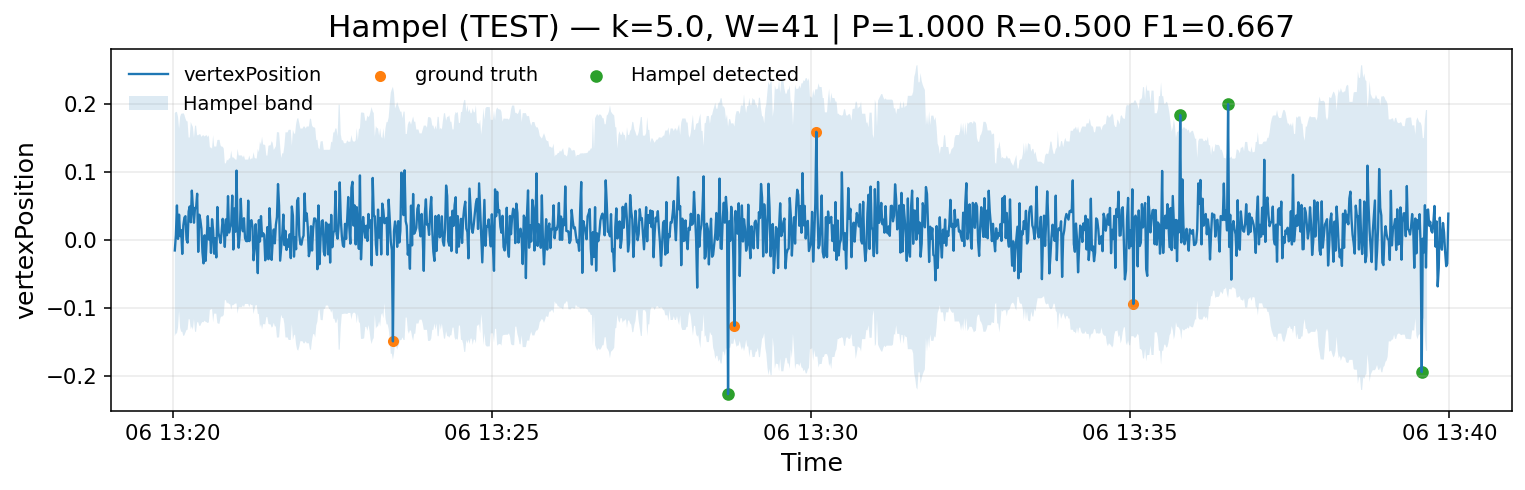

saved: figs/hampel_detections_caseA.png
OCSVM(test) nu=0.005, gamma=0.1, tau=0.25 => P=0.571 R=0.500 F1=0.533 [val: P=0.783 R=1.000 F1=0.878]


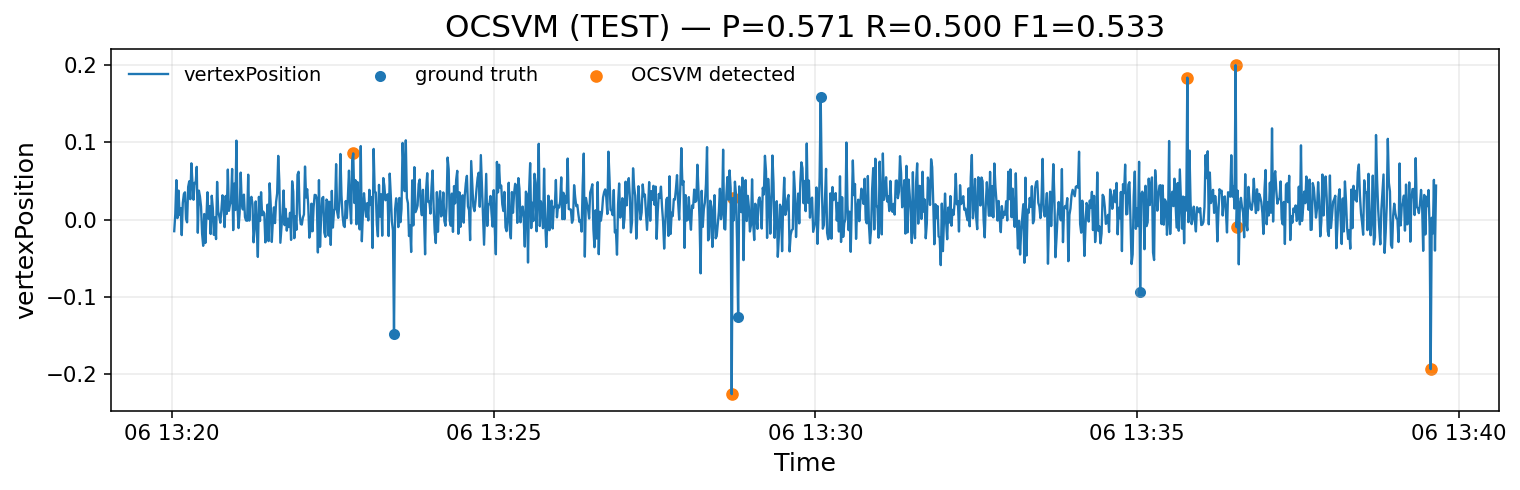

saved: figs/ocsvm_prec_detections_caseA.png


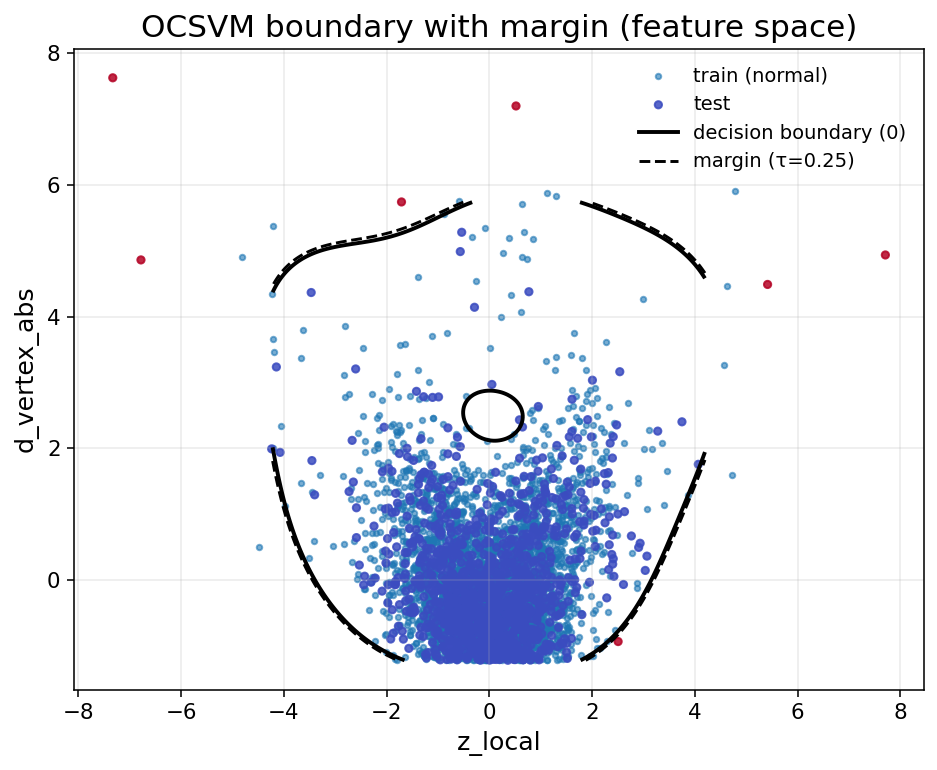

saved: figs/ocsvm_prec_boundary_caseA.png


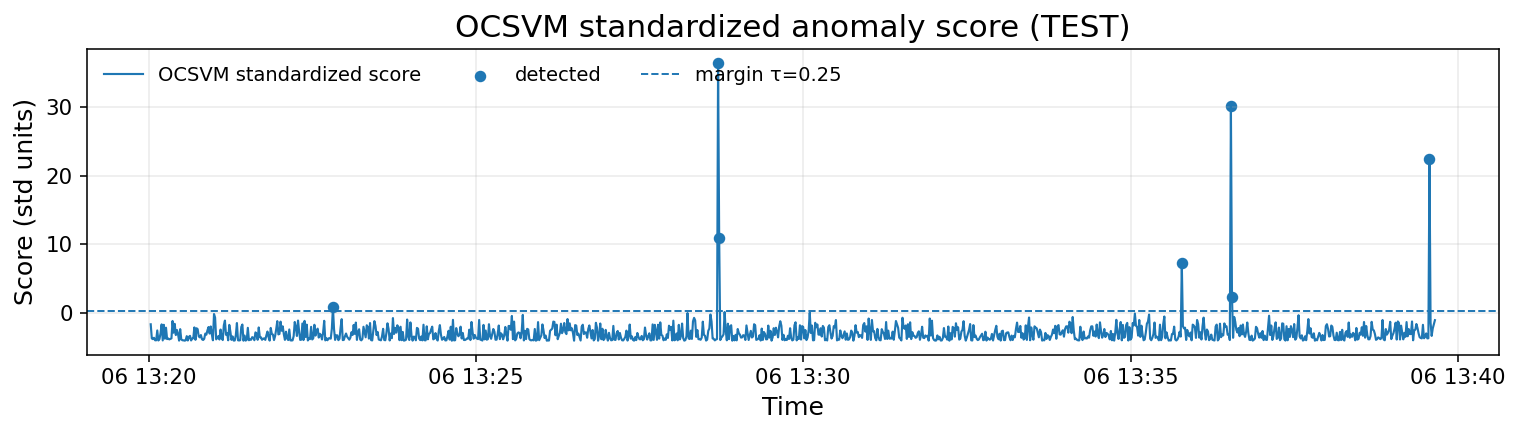

saved: figs/ocsvm_prec_score_caseA.png


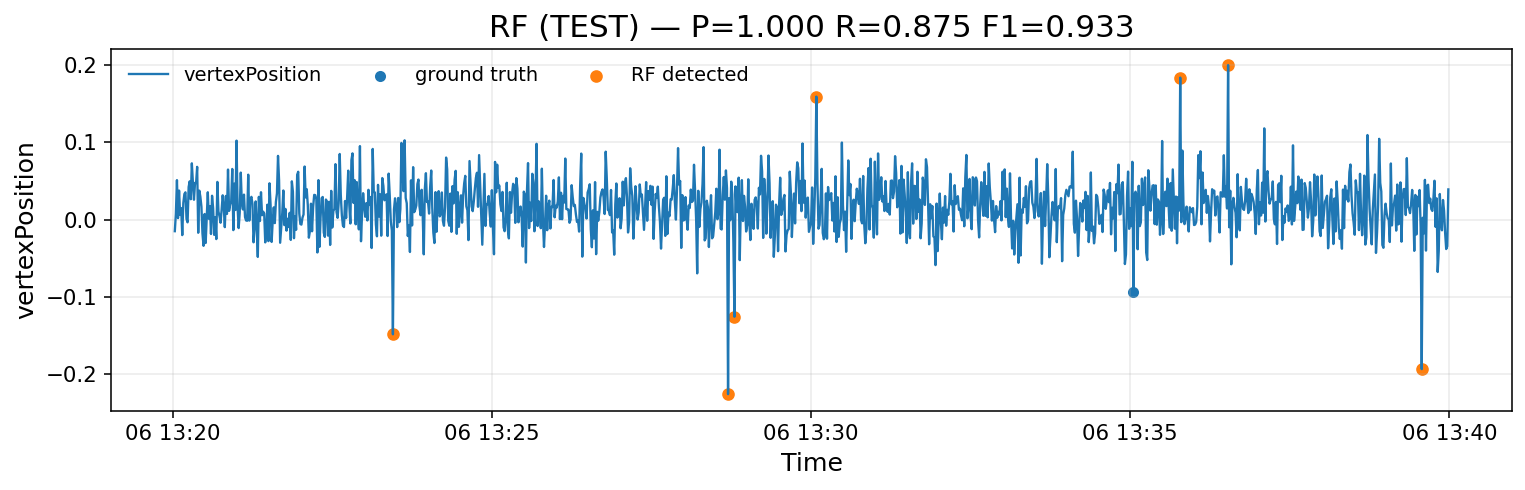

saved: figs/rf_detections_caseA.png


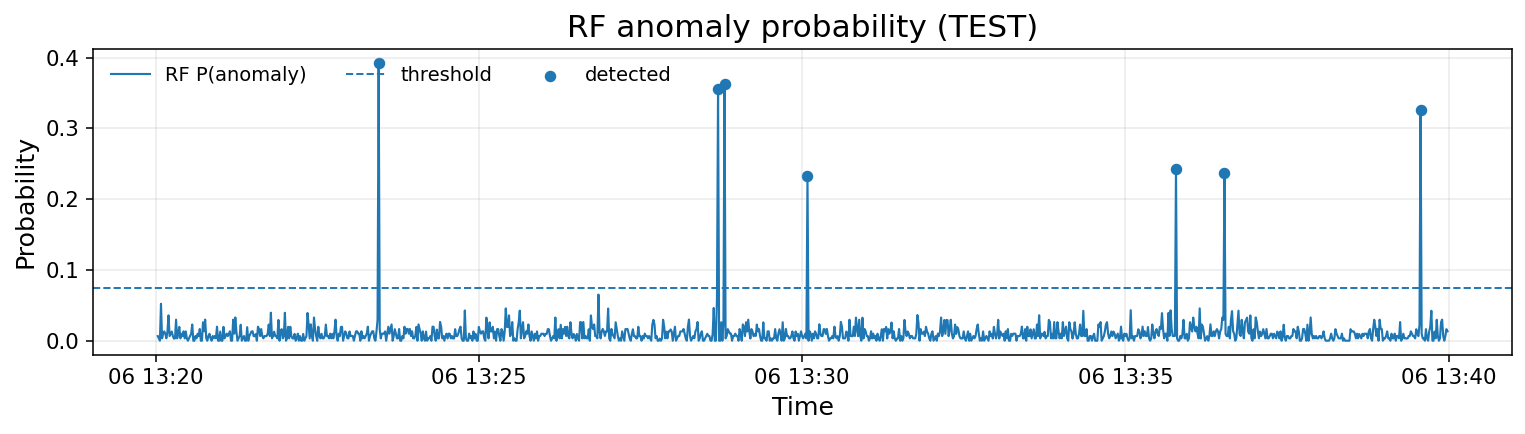

saved: figs/rf_probability_caseA.png


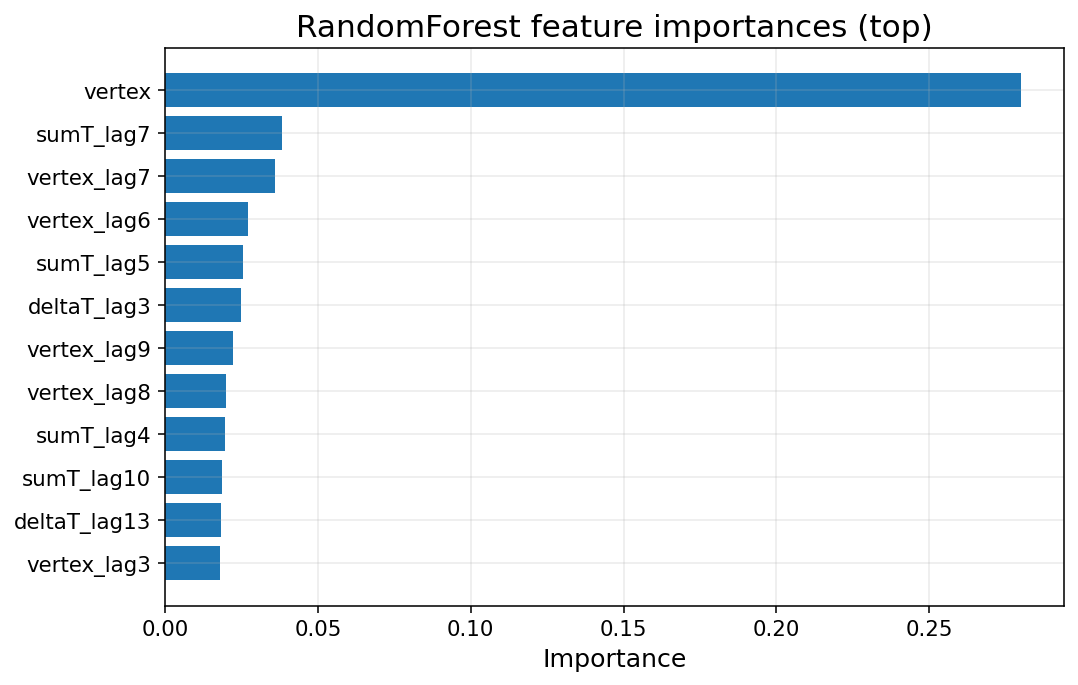

saved: figs/rf_importances_caseA.png


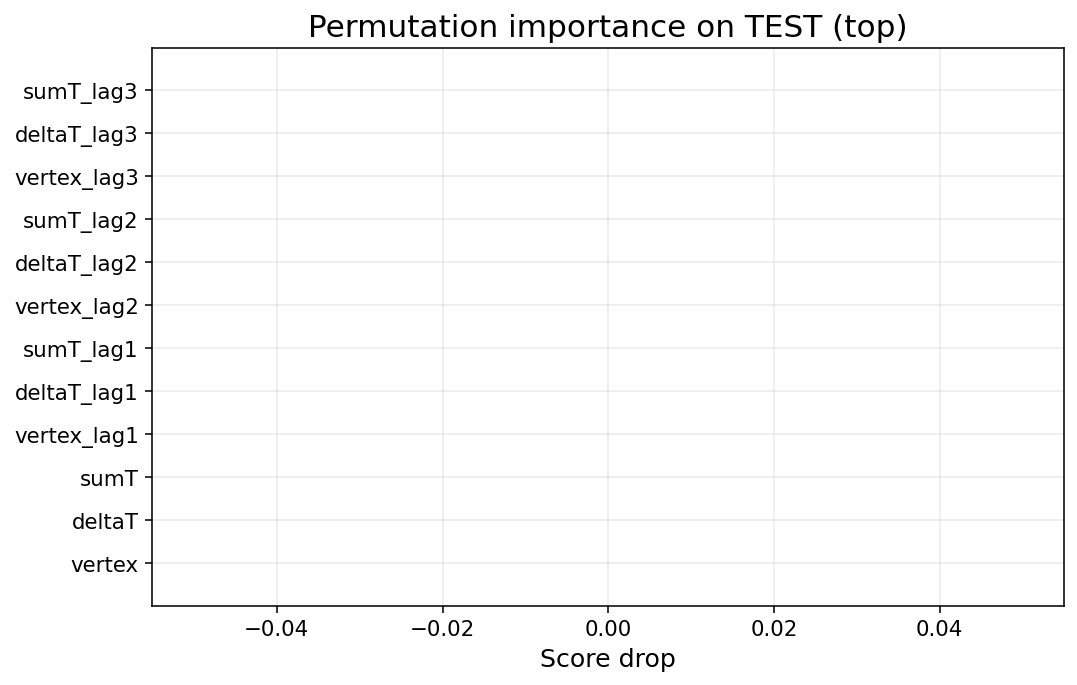

saved: figs/rf_perm_importances_caseA.png


In [62]:
# 1) Hampel (test-only), save figure
h_metrics = hampel_pubplot(
    syn["vertexPosition"], truth,
    test_idx=rf_res["test_idx"], k=5.0, W=41,
    outdir="figs", tag="caseA"
)

# 2) OCSVM (test-only), aligned to RF splits, save figures
oc_res = ocsvm_precision_tuned_explain(
    df=syn, truth=truth,
    rf_split=dict(train_idx=rf_res["train_idx"], val_idx=rf_res["val_idx"], test_idx=rf_res["test_idx"]),
    window=41,
    nu_grid=(0.002, 0.005, 0.01),
    gamma_grid=("scale","auto", 0.1, 0.2, 0.5, 1.0),
    margin_grid=(0.0, 0.25, 0.5, 1.0, 1.5, 2.0),
    tolerance=2, purify_q=0.99,
    outdir="figs", tag="caseA",
    optimize="F1"   # set to "precision" if you need even higher precision (at some recall loss)
)

# 3) RF pub-quality plots (detections, prob, importances), save figures
rf_pubplots(rf_res, syn, truth, outdir="figs", tag="caseA")

OCSVM(test) nu=0.005, gamma=0.2, tau=1.5 => P=0.667 R=0.500 F1=0.571 [val: P=0.810 R=0.944 F1=0.872]


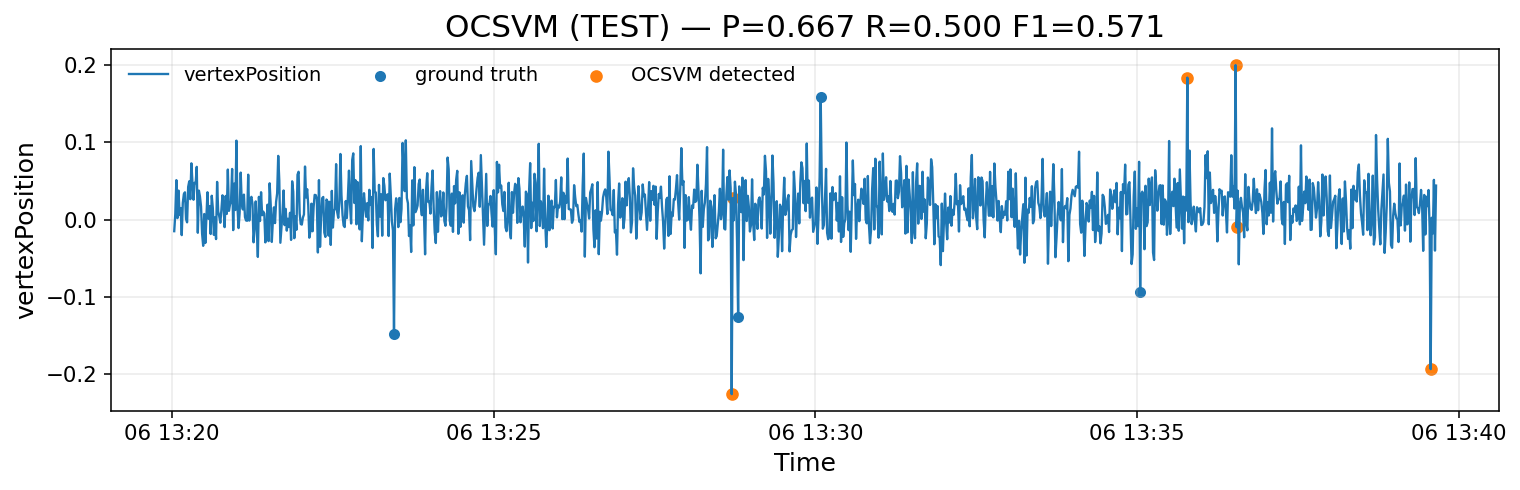

saved: figs/ocsvm_prec_detections_caseA.png


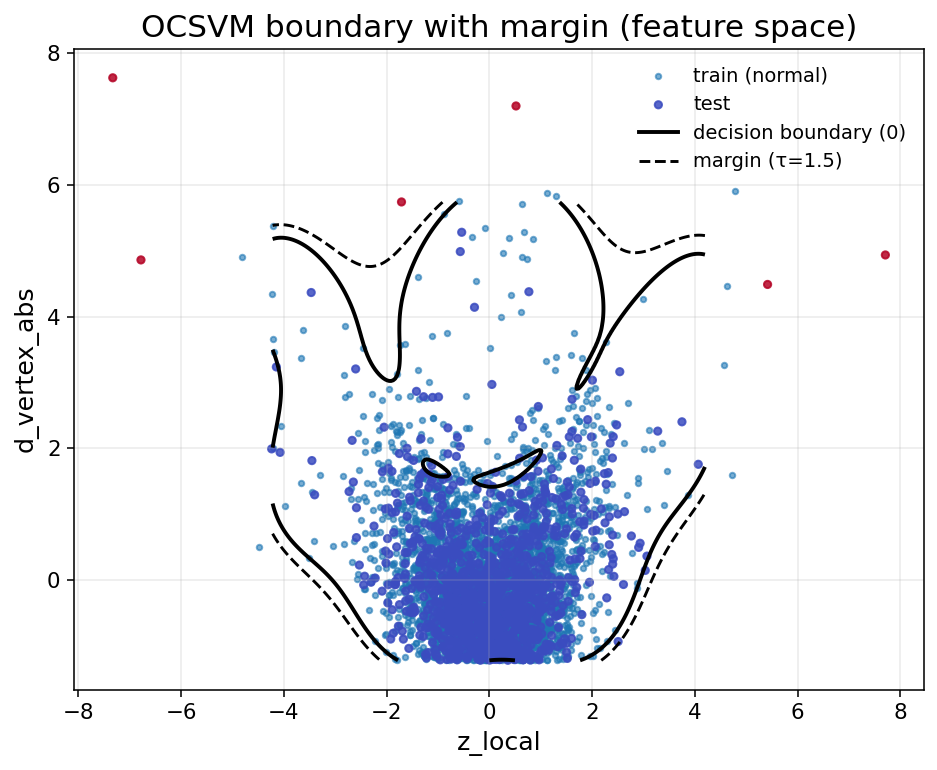

saved: figs/ocsvm_prec_boundary_caseA.png


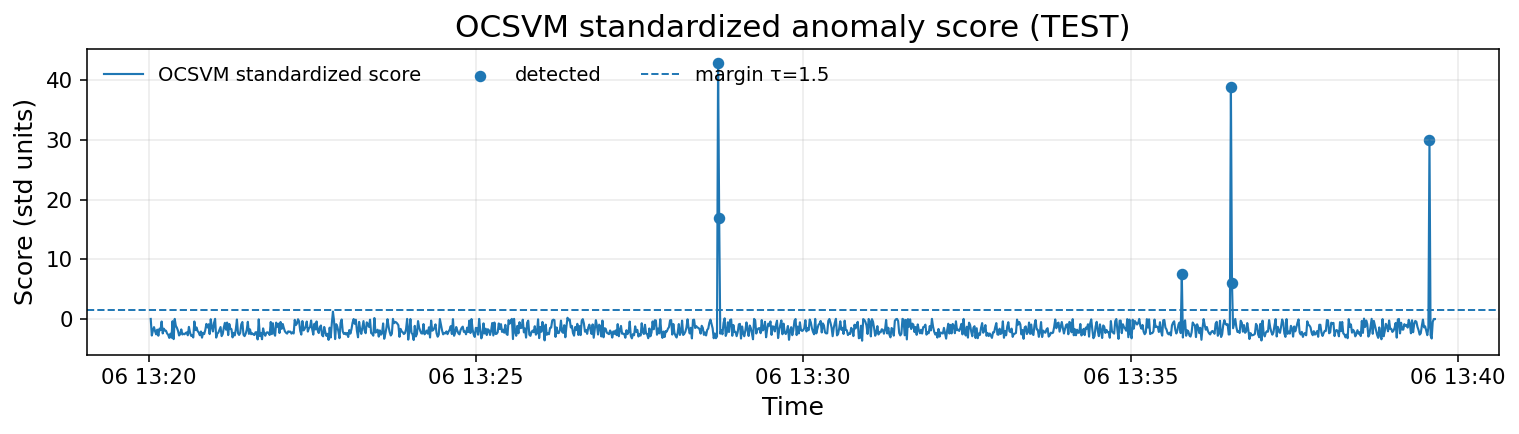

saved: figs/ocsvm_prec_score_caseA.png


In [58]:
oc_res = ocsvm_precision_tuned_explain(
    df=syn, truth=truth,
    rf_split=dict(train_idx=rf_res["train_idx"], val_idx=rf_res["val_idx"], test_idx=rf_res["test_idx"]),
    window=41,
    nu_grid=(0.002, 0.005, 0.01),
    gamma_grid=("scale","auto", 0.1, 0.2, 0.5, 1.0),
    margin_grid=(0.0, 0.25, 0.5, 1.0, 1.5, 2.0),
    tolerance=2, purify_q=0.99,
    outdir="figs", tag="caseA",
    optimize="F1"   # set to "precision" if you need even higher precision (at some recall loss)
)

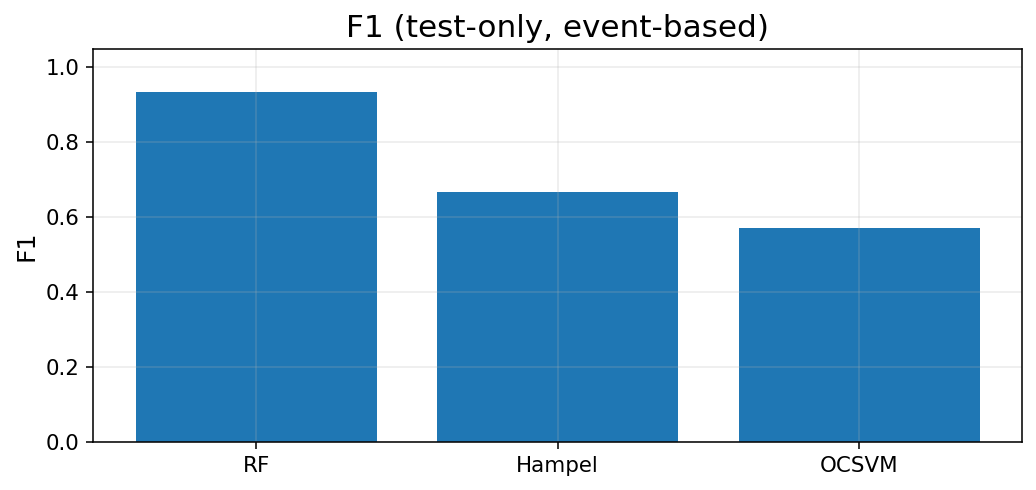

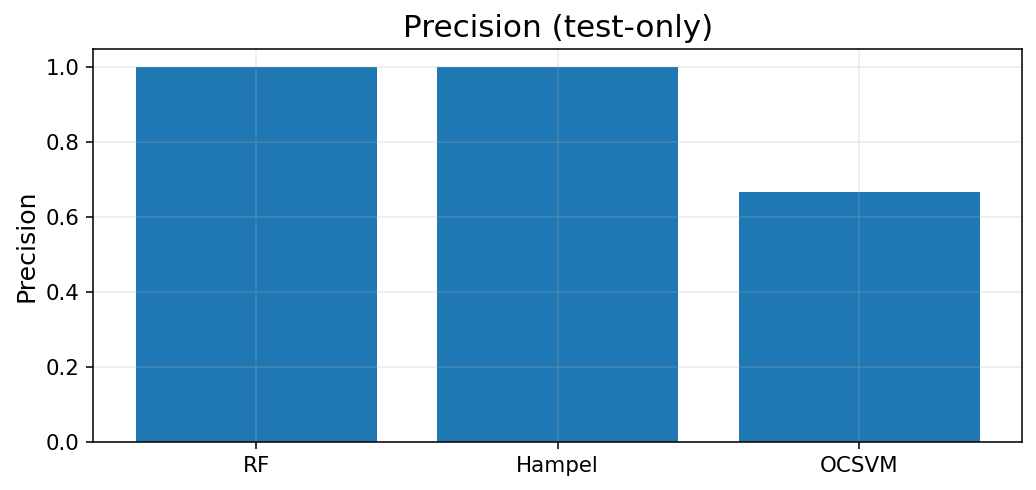

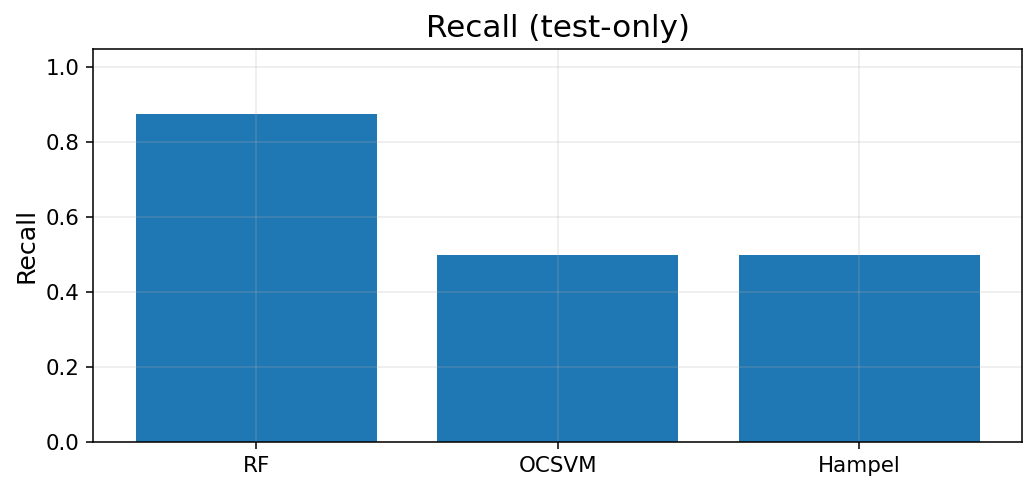

In [60]:
labels = ["Hampel", "OCSVM", "RF"]
prec = [h_metrics["precision"], oc_res["metrics_test"]["precision"], rf_res["metrics_test"]["precision"]]
rec  = [h_metrics["recall"],    oc_res["metrics_test"]["recall"],    rf_res["metrics_test"]["recall"]]
f1   = [h_metrics["f1"],        oc_res["metrics_test"]["f1"],        rf_res["metrics_test"]["f1"]]

# Publication-quality bars
def bars(vals, labs, title, ylabel):
    order = np.argsort(vals)[::-1]
    vals = np.array(vals)[order]; labs = np.array(labs)[order]
    plt.figure(figsize=(7.5,3.6))
    plt.bar(range(len(vals)), vals)
    plt.xticks(range(len(vals)), labs, rotation=0)
    plt.title(title); plt.ylabel(ylabel); plt.ylim(0, 1.05); plt.tight_layout(); plt.show()

bars(f1,  labels, "F1 (test-only, event-based)", "F1")
bars(prec,labels, "Precision (test-only)", "Precision")
bars(rec, labels,  "Recall (test-only)", "Recall")

In [68]:
# Synthetic figures + parameter table for EnergyTwin V2
# (No internet; matplotlib only; single-plot figures; no custom colors.)

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from datetime import datetime, timedelta

# --------------------
# Parameters (defaults used in figures)
# --------------------
params = {
    "P_rated": 100.0,          # kW
    "eta_STC": 0.20,           # unitless
    "alpha": -0.004,           # per °C
    "U0": 25.0,                # W/m^2/K
    "U1": 6.0,                 # W/m^2/K per (m/s)
    "v_w": 2.0,                # m/s
    "E_max": 200.0,            # kWh
    "gamma_min": 0.10,         # min SOC fraction
    "eta_c": 0.95,             # charging efficiency
    "eta_d": 0.95,             # discharging efficiency
    "P_ch_max": 100.0,         # kW
    "P_dis_max": 100.0,        # kW
    "dt_h": 1.0                # hours
}

symbol_rows = [
    ("$P_{\\mathrm{rated}}$", "PV array STC rating", "kW", params["P_rated"]),
    ("$\\eta_{\\mathrm{STC}}$", "Module efficiency at STC", "–", params["eta_STC"]),
    ("$\\alpha$", "Temperature coefficient", "$\\mathrm{\\,per\\,^{\\circ}C}$", params["alpha"]),
    ("$U_0$", "Thermal loss factor", "$\\mathrm{W\\,m^{-2}\\,K^{-1}}$", params["U0"]),
    ("$U_1$", "Wind-dependent loss factor", "$\\mathrm{W\\,m^{-2}\\,K^{-1}\\,(m/s)^{-1}}$", params["U1"]),
    ("$v_w$", "Wind speed", "$\\mathrm{m\\,s^{-1}}$", params["v_w"]),
    ("$E_{\\max}$", "Battery energy capacity", "kWh", params["E_max"]),
    ("$\\gamma_{\\min}$", "Min. SOC fraction", "–", params["gamma_min"]),
    ("$\\eta_c$", "Charging efficiency", "–", params["eta_c"]),
    ("$\\eta_d$", "Discharging efficiency", "–", params["eta_d"]),
    ("$P_{\\mathrm{ch}}^{\\max}$", "Max charging power", "kW", params["P_ch_max"]),
    ("$P_{\\mathrm{dis}}^{\\max}$", "Max discharging power", "kW", params["P_dis_max"]),
    ("$\\Delta t$", "Time-step", "h", params["dt_h"]),
]

df_symbols = pd.DataFrame(symbol_rows, columns=["Symbol", "Description", "Units", "Default value"])

# Save CSV and display
symbols_csv_path = "twin/energy_twin_symbol_table.csv"
df_symbols.to_csv(symbols_csv_path, index=False)

# --------------------
# Synthetic 24h time grid
# --------------------
T = 24
t = np.arange(T)  # hours 0..23
dt = params["dt_h"]

# --------------------
# Synthetic irradiance & temperature model
# --------------------
# Clear-sky POA approximation (bell around noon); peak ~1000 W/m^2
poa_clear = np.maximum(0.0, np.sin(np.pi * (t - 6) / 12.0)) * 1000.0

# Cloud factor kappa: piecewise to mimic changing sky
kappa = np.ones(T)
kappa[10:15] = 0.7
kappa[15:18] = 0.3

poa = poa_clear * kappa

# Ambient temperature: base + diurnal
T_avg = 20.0
A_day = 6.0
h0 = 15.0
T_amb = T_avg + A_day * np.cos(2 * np.pi * (t - h0) / 24.0)

# Faiman module temperature
U0, U1, v_w = params["U0"], params["U1"], params["v_w"]
T_pv = T_amb + poa / (U0 + U1 * v_w)

# Relative efficiency
eta_STC = params["eta_STC"]
alpha = params["alpha"]
eta_rel = eta_STC * (1.0 + alpha * (T_pv - 25.0))
eta_rel = np.clip(eta_rel, 0.01, None)  # avoid negatives in synthetic

# PV power
P_rated = params["P_rated"]
C_t = np.ones(T)
P_pv = P_rated * eta_rel * (poa / 1000.0) * C_t

# --------------------
# Synthetic load (kW): base + morning/evening peaks
# --------------------
def gaussian(x, mu, sigma, amp):
    return amp * np.exp(-0.5 * ((x - mu) / sigma) ** 2)

L_base = 30.0
L = L_base + gaussian(t, 8.0, 2.5, 15.0) + gaussian(t, 19.0, 2.5, 40.0)
# small noise
rng = np.random.default_rng(42)
L += rng.normal(0, 1.0, size=T)

# --------------------
# Time-of-use price (€/kWh) for grid imports
# --------------------
price = np.where((t >= 18) & (t <= 22), 0.40, np.where((t >= 8) & (t <= 17), 0.20, 0.10))

# --------------------
# Dispatch helpers
# --------------------
E_max = params["E_max"]
E_min = params["gamma_min"] * E_max
eta_c = params["eta_c"]
eta_d = params["eta_d"]
P_ch_max = params["P_ch_max"]
P_dis_max = params["P_dis_max"]

def baseline_dispatch(PV, load):
    E = 0.5 * E_max
    soc = np.zeros(T)
    P_batt = np.zeros(T)  # +discharge, -charge
    grid = np.zeros(T)
    for i in range(T):
        residual = load[i] - PV[i]  # + need, - surplus

        if residual > 0:
            # Discharge battery to cover load
            # Max energy deliverable this period limited by SOC and P_dis_max
            P_dis_limit_by_soc = eta_d * E / dt  # kW
            P_dis = min(P_dis_max, residual, P_dis_limit_by_soc)
            # Update battery
            E -= (P_dis * dt) / eta_d
            residual -= P_dis
            P_batt[i] = P_dis  # positive = discharge
        else:
            # Surplus PV -> charge battery
            surplus = -residual
            P_ch_limit_by_cap = (E_max - E) / (eta_c * dt)
            P_ch = min(P_ch_max, surplus, P_ch_limit_by_cap)
            E += eta_c * P_ch * dt
            residual += P_ch
            P_batt[i] = -P_ch  # negative = charge
            # Remaining residual < 0 is curtailed

        # Grid covers any unmet
        grid[i] = max(0.0, residual)
        # Enforce SOC bounds
        E = max(E_min, min(E, E_max))
        soc[i] = E
    return soc, P_batt, grid

def predictive_dispatch(PV, load, price):
    E = 0.5 * E_max
    soc = np.zeros(T)
    P_batt = np.zeros(T)
    grid = np.zeros(T)

    # Precompute net deficit in evening window
    evening_mask = (t >= 18) & (t <= 22)
    # Estimate target energy to cover evening deficit (1-hour steps)
    deficit_evening = np.sum(np.maximum(0.0, load[evening_mask] - PV[evening_mask]))
    E_target = min(E_max, deficit_evening / eta_d)

    for i in range(T):
        residual = load[i] - PV[i]

        # If before evening and below target SOC, prefer charging (even with grid if cheap)
        if i < 18 and (E < E_target):
            # Try to charge from PV surplus first
            if residual < 0:
                surplus = -residual
                P_ch_limit_by_cap = (E_max - E) / (eta_c * dt)
                P_ch = min(P_ch_max, surplus, P_ch_limit_by_cap)
                E += eta_c * P_ch * dt
                residual += P_ch
                P_batt[i] = -P_ch
            # If still below target and price is low, grid-charge
            if (E < E_target) and (price[i] <= 0.20):
                P_ch_limit_by_cap = (E_max - E) / (eta_c * dt)
                P_ch_grid = min(P_ch_max, P_ch_limit_by_cap)
                if P_ch_grid > 0:
                    E += eta_c * P_ch_grid * dt
                    grid[i] += P_ch_grid  # import to charge
                    P_batt[i] -= P_ch_grid  # charging
                residual = max(0.0, residual)  # any remaining surplus curtailed
        else:
            # After 18: use battery aggressively to reduce grid
            if residual > 0:
                P_dis_limit_by_soc = eta_d * E / dt
                P_dis = min(P_dis_max, residual, P_dis_limit_by_soc)
                E -= (P_dis * dt) / eta_d
                residual -= P_dis
                P_batt[i] = P_dis
            elif residual < 0:
                surplus = -residual
                P_ch_limit_by_cap = (E_max - E) / (eta_c * dt)
                P_ch = min(P_ch_max, surplus, P_ch_limit_by_cap)
                E += eta_c * P_ch * dt
                residual += P_ch
                P_batt[i] = -P_ch
            # Remaining residual < 0 is curtailed

        # Grid supplies unmet demand
        grid[i] += max(0.0, residual)

        # Enforce SOC bounds
        E = max(E_min, min(E, E_max))
        soc[i] = E

    return soc, P_batt, grid

soc_base, Pb_base, grid_base = baseline_dispatch(P_pv, L)
soc_pred, Pb_pred, grid_pred = predictive_dispatch(P_pv, L, price)

cost_base = np.cumsum(grid_base * price * dt)
cost_pred = np.cumsum(grid_pred * price * dt)

# --------------------
# FIGURE 1: PV pipeline diagram
# --------------------
fig1_path = "twin/fig1_pv_pipeline.png"
plt.figure(figsize=(8, 5))
plt.axis('off')

# nodes (x,y), text
nodes = {
    "clear": ((0.05, 0.7), "Clear-sky\nGHI/DNI/DHI"),
    "transp": ((0.35, 0.7), "Transposition\n(tilt, azimuth,\nsolar position)"),
    "poa": ((0.65, 0.7), "POA irradiance\n$I_{\\mathrm{POA}}(t)$"),
    "temp": ((0.35, 0.35), "Faiman model\n$T_{\\mathrm{PV}}(t)$"),
    "eff": ((0.65, 0.35), "Rel. efficiency\n$\\eta_{\\mathrm{rel}}(t)$"),
    "power": ((0.85, 0.35), "PV power\n$P_{\\mathrm{PV}}(t)$")
}

def draw_box(ax, xy, text):
    x, y = xy
    bbox_props = dict(boxstyle="round,pad=0.4", ec="black", fc="white")
    ax.text(x, y, text, ha="center", va="center", bbox=bbox_props, fontsize=10)

ax = plt.gca()
for k,(xy,txt) in nodes.items():
    draw_box(ax, xy, txt)

# arrows
def arrow(p1, p2):
    ax.annotate("", xy=p2, xytext=p1, arrowprops=dict(arrowstyle="->"))

arrow((0.17,0.7), (0.28,0.7))  # clear -> transp
arrow((0.45,0.7), (0.58,0.7))  # transp -> poa
arrow((0.65,0.62), (0.65,0.43))  # poa -> eff
arrow((0.20,0.20), (0.33,0.30))  # T_amb & wind (label)
ax.text(0.14,0.18,"$T_{\\mathrm{amb}}, v_w$", fontsize=9)
arrow((0.15,0.18), (0.33,0.32))  # to Faiman
arrow((0.52,0.35), (0.58,0.35))  # temp -> eff
arrow((0.72,0.35), (0.80,0.35))  # eff -> power
ax.text(0.70,0.55,"$C(t)$", fontsize=9)
arrow((0.70,0.54), (0.70,0.40))  # C(t) to efficiency/power

plt.tight_layout()
plt.savefig(fig1_path, dpi=200, bbox_inches="tight")
plt.close()

# --------------------
# FIGURE 2: Scenario tree (3-branch x 2 steps)
# --------------------
fig2_path = "twin/fig2_scenario_tree.png"
plt.figure(figsize=(8, 5))
ax = plt.gca()
ax.axis('off')

root = (0.05, 0.5)
ax.text(*root, "t=0\n(state)", ha="center", va="center", bbox=dict(boxstyle="round", ec="black", fc="white"))

lvl1_y = [0.75, 0.5, 0.25]  # high, nominal, low
lvl1 = [(0.35, y) for y in lvl1_y]
labels1 = ["High", "Nominal", "Low"]
for (x,y),lab in zip(lvl1, labels1):
    ax.text(x, y, f"t=1\n{lab}", ha="center", va="center", bbox=dict(boxstyle="round", ec="black", fc="white"))
    ax.annotate("", xy=(x-0.12,y), xytext=root, arrowprops=dict(arrowstyle="-"))

lvl2_offsets = [0.12, 0.0, -0.12]
for i,(x1,y1) in enumerate(lvl1):
    for j,dy in enumerate(lvl2_offsets):
        x2, y2 = 0.65, y1 + dy
        lab = ["H","N","L"][j]
        ax.text(x2, y2, f"t=2\n{lab}", ha="center", va="center",
                bbox=dict(boxstyle="round", ec="black", fc="white"))
        ax.annotate("", xy=(x2-0.12,y2), xytext=(x1+0.12,y1), arrowprops=dict(arrowstyle="-"))

ax.text(0.88, 0.5, "Non-anticipative action at t=0\n(shared across scenarios)",
        ha="center", va="center")

plt.tight_layout()
plt.savefig(fig2_path, dpi=200, bbox_inches="tight")
plt.close()

# --------------------
# FIGURE 3: PV vs Load
# --------------------
fig3_path = "twin/fig3_pv_vs_load.png"
plt.figure(figsize=(9, 4.5))
plt.plot(t, P_pv, label="PV (kW)")
plt.plot(t, L, label="Load (kW)")
plt.xlabel("Hour")
plt.ylabel("Power (kW)")
plt.title("Synthetic PV and Load Profiles (24h)")
plt.legend()
plt.tight_layout()
plt.savefig(fig3_path, dpi=200, bbox_inches="tight")
plt.close()

# --------------------
# FIGURE 4: Battery power (baseline vs predictive)
# --------------------
fig4_path = "twin/fig4_battery_power.png"
plt.figure(figsize=(9, 4.5))
plt.plot(t, Pb_base, label="Battery power (baseline)")
plt.plot(t, Pb_pred, label="Battery power (predictive)")
plt.axhline(0, linestyle="--")
plt.xlabel("Hour")
plt.ylabel("kW (+discharge, −charge)")
plt.title("Battery Dispatch")
plt.legend()
plt.tight_layout()
plt.savefig(fig4_path, dpi=200, bbox_inches="tight")
plt.close()

# --------------------
# FIGURE 5: SOC (baseline vs predictive)
# --------------------
fig5_path = "twin/fig5_soc.png"
plt.figure(figsize=(9, 4.5))
plt.plot(t, soc_base, label="SOC (baseline)")
plt.plot(t, soc_pred, label="SOC (predictive)")
plt.xlabel("Hour")
plt.ylabel("Energy (kWh)")
plt.title("Battery State of Charge")
plt.legend()
plt.tight_layout()
plt.savefig(fig5_path, dpi=200, bbox_inches="tight")
plt.close()

# --------------------
# FIGURE 6: Cumulative cost (baseline vs predictive)
# --------------------
fig6_path = "twin/fig6_cumcost.png"
plt.figure(figsize=(9, 4.5))
plt.plot(t, cost_base, label="Cumulative cost (baseline)")
plt.plot(t, cost_pred, label="Cumulative cost (predictive)")
plt.xlabel("Hour")
plt.ylabel("€")
plt.title("Cumulative Grid Cost (TOU pricing)")
plt.legend()
plt.tight_layout()
plt.savefig(fig6_path, dpi=200, bbox_inches="tight")
plt.close()

# Return file paths so the UI can show links in the assistant message
(fig1_path, fig2_path, fig3_path, fig4_path, fig5_path, fig6_path, symbols_csv_path)

('twin/fig1_pv_pipeline.png',
 'twin/fig2_scenario_tree.png',
 'twin/fig3_pv_vs_load.png',
 'twin/fig4_battery_power.png',
 'twin/fig5_soc.png',
 'twin/fig6_cumcost.png',
 'twin/energy_twin_symbol_table.csv')